## Packages and Files

### Packages

In [1]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np # type: ignore

from tabulate import tabulate # type: ignore

### Files

In [2]:
def read_file(transistors_params, l_value, sizing_ratios, k_value, cols_indexes, cols_names):
    """
    Read file

    Parameters:
    - transistors_params (dict): Dictionary of file paths keyed by lengths
    - l_value (int): Transistor length
    - sizing_ratios (dict): Dictionary of sizing ratios keyed by column indexes
    - k_value (float): Sizing ratio
    - cols_indexes (array int): Columns indexes
    - cols_names (array str): Columns names
        
    Returns:
    - data (df): Specified data
    """
    # Validate inputs
    if l_value not in transistors_params:
        raise ValueError(f"Error: Transistor length {l_value} nm not found in file paths.")
    
    if k_value is not None:
        if sizing_ratios is None or k_value not in sizing_ratios.values():
            raise ValueError(f"Error: Sizing ratio {k_value} not found in sizing_ratios.")
        row_idx = list(sizing_ratios.keys())[list(sizing_ratios.values()).index(k_value)]
    else:
        row_idx = None
    
    # Select file path by length
    trans_param = transistors_params[l_value]
    
    # Read the CSV file directly
    try:
        df = pd.read_csv(trans_param, usecols=cols_indexes, names=cols_names, header=None)
    except Exception as e:
        raise ValueError(f"Error reading CSV file: {e}")
    
    # Get the specified row for the given k_value if provided
    if row_idx is not None:
        try:
            data = df.iloc[row_idx]
        except IndexError as e:
            raise IndexError(f"Error accessing row index: {e}")
    else:
        data = df  
    
    return data

## Diode Inverter Efficiency

### Transconductance Efficiency

In [3]:
def plot_inv_transconductance_efficiency_diff_lengths(transistors_params, sizing_ratios=None, k_value=None):
    """
    Plot inverter transconductance efficiency for different lengths

    Parameters:
    - transistors_params (dict): Dictionary of file paths keyed by lengths
    - sizing_ratios (dict, optional): Dictionary of sizing ratios keyed by column indexes
    - k_value (float, optional): Sizing ratio
    """
    # Define constants for column indices and names
    nmos_gmid_index = 11
    nmos_gmgds_ft_idwl_indexes = [12, 13, 14]
    
    pmos_gmid_index = 25
    pmos_gmgds_ft_idwl_indexes = [26, 27, 28]

    gmid_name = '$g_m/I_D$'
    gmgds_ft_idwl_names = ['$g_m/g_{ds}$', '$f_T$', '$I_D/W$']
    
    _ = 'Transconductance Efficiency'
    gmgds_ft_idwl_descriptions = ['Self Gain', 'Transit Frequency', 'Normalized Current']
    
    gmid_unit = ' $(V^{-1})$'
    gmgds_ft_idwl_units = ['', '$(Hz)$', '$(A/m)$']
    
    # Number of graphs to plot
    num_gphs = len(gmgds_ft_idwl_names)  
    
    # Create subplots for NMOS and PMOS metrics side by side
    fig, axes = plt.subplots(nrows=num_gphs, ncols=2, figsize=(16, 2 * num_gphs))  
    
    # Store lines and labels for legend
    nmos_lines = []
    pmos_lines = []
    nmos_labels = []
    pmos_labels = []
    
    for l_value, trans_param in transistors_params.items():
        
        for j in range(num_gphs):
            # NMOS
            nmos_metric_index = nmos_gmgds_ft_idwl_indexes[j]
            nmos_metric_name = gmgds_ft_idwl_names[j]
            nmos_metric_description = gmgds_ft_idwl_descriptions[j]
            nmos_metric_unit = gmgds_ft_idwl_units[j]

            # Read the CSV file and extract NMOS metrics
            nmos_df = read_file(transistors_params, l_value, sizing_ratios, k_value, [nmos_gmid_index, nmos_metric_index], [gmid_name, nmos_metric_name])
            
            # Plot NMOS metrics against gm/ID 
            nmos_line, = axes[j, 0].plot(nmos_df[gmid_name], nmos_df[nmos_metric_name], label=f'$L = {l_value}$ $nm')  
            
            # Only store labels once
            if j == 2:
                nmos_lines.append(nmos_line)
                nmos_labels.append(f'$L = {l_value}$ $nm$')

            # Set NMOS plot titles, labels, grid and limits 
            axes[j, 0].set_title(f'NMOS {nmos_metric_description}')
            axes[j, 0].set_xlabel(f'{gmid_name} {gmid_unit}')
            axes[j, 0].set_ylabel(f'{nmos_metric_name} {nmos_metric_unit}')
            axes[j, 0].set_yscale('log')
            axes[j, 0].grid(True)
            axes[j, 0].set_xlim([3, 9])
            
            # PMOS
            pmos_metric_index = pmos_gmgds_ft_idwl_indexes[j]
            pmos_metric_name = gmgds_ft_idwl_names[j]
            pmos_metric_description = gmgds_ft_idwl_descriptions[j]
            pmos_metric_unit = gmgds_ft_idwl_units[j]

            # Read the CSV file and extract PMOS metrics
            pmos_df = read_file(transistors_params, l_value, sizing_ratios, k_value, [pmos_gmid_index, pmos_metric_index], [gmid_name, pmos_metric_name])
            
            # Plot PMOS metrics against gm/ID 
            pmos_line, = axes[j, 1].plot(pmos_df[gmid_name], pmos_df[pmos_metric_name])  
            
            # Only store labels once
            if j == 2:
                pmos_lines.append(pmos_line)
                pmos_labels.append(f'$L = {l_value}$ $nm$')

            # Set PMOS plot titles, labels, grid and limits 
            axes[j, 1].set_title(f'PMOS {pmos_metric_description}')
            axes[j, 1].set_xlabel(f'{gmid_name} {gmid_unit}')
            axes[j, 1].set_ylabel(f'{pmos_metric_name} {pmos_metric_unit}')
            axes[j, 1].set_yscale('log')
            axes[j, 1].grid(True)
            axes[j, 1].set_xlim([3, 9])

            # Customize y-axis ticks to avoid intermediate labels
            axes[j, 0].yaxis.set_major_locator(plt.LogLocator(base=10.0))
            axes[j, 1].yaxis.set_major_locator(plt.LogLocator(base=10.0))

    # Adjust subplot layout to prevent overlap
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Create legends for NMOS and PMOS
    fig.legend(nmos_lines, nmos_labels, loc='upper center', bbox_to_anchor=(0.3, 0), ncol=3, fontsize=10, frameon=False, bbox_transform=plt.gcf().transFigure)
    fig.legend(pmos_lines, pmos_labels, loc='upper center', bbox_to_anchor=(0.75, 0), ncol=3, fontsize=10, frameon=False, bbox_transform=plt.gcf().transFigure)
    
    # Display the plot
    plt.show()

### Trip Point

In [4]:
def plot_inv_trip_point_diff_lengths(transistors_params):
    """
    Plot inverter trip point for different lengths
    
    Parameters:
    - transistors_params (dict): Dictionary containing file paths keyed by lengths
    """
    # Define constants for column indices and names
    k_idx = 0
    vgs_idx = 2
    
    k_name = '$k_W$'
    vgs_name = '$V_{TP}$'
    
    _ = 'Sizing Ratio'
    vgs_name_ = 'Trip Point Voltage against Width Ratio Factor'
    k_unit = ''
    vgs_unit = '$(V)$'

    # Create single plot
    fig, ax = plt.subplots(figsize=(8, 3))
    
    # Ensure x-axis is set to log scale
    ax.set_xscale('log')

    for l_value, trans_param in transistors_params.items():

        # Read CSV file and extract Vgs and k columns
        df = read_file(transistors_params, l_value, None, None, [k_idx, vgs_idx], [k_name, vgs_name])
        
        vgs_mV = df[vgs_name]
        
        # Plot Vgs vs. k for the current L value
        ax.semilogx(df[k_name], vgs_mV, marker='o', label=f'$L = {l_value}$ $nm$')

    # Set plot title, labels, and grid
    ax.set_title(f'\n{vgs_name_}', fontsize=12)  # Add newline for space
    ax.set_xlabel(f'{k_name} {k_unit}', fontsize=10)
    ax.set_ylabel(f'{vgs_name} {vgs_unit}', fontsize=10)
    ax.axhline(y=0.6, color='r', linestyle='--')
    ax.grid(True)
    
    # Adjust subplot layout to prevent overlap
    plt.tight_layout() 

    # Create a single horizontal legend just above the last subplot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, fontsize=10, frameon=False, bbox_transform=plt.gcf().transFigure)

    # Display the plot
    plt.show()

## Ring Amplifier Perfomance Close Loop

In [5]:
def calc_ramp_performance_cl(VDD, N, CF):
    """
    Calculate ring amplifier perfomance in close loop

    Parameters:
    - N (int): Resolution
    - CF (float): Feedback cpacitance 
    
    Returns:
    - Af (float): Feedback gain
    - B (float): Feedback factor
    - CS, CL (float): Source and load capacitances
    
    """
    # Determine feedback gain (V/V)
    Af = 2 ** (N - 1)

    # Determine the source and load capacitances (F)
    CS = CF * (Af - 1)
    CL = Af * CF

    # Determine the feedback factor           *** considering the flip-around ***
    β  = CF / (CS + CF)                  
    
    # Determine the input and output common mode voltages (V)
    Vcmin = VDD / 2
    Vcmout = VDD / 2
    
    return Af, β, CS, CL, Vcmin, Vcmout



def print_ramp_perfomance_cl(Af, β , CF, CS, CL, VDD, Vcmin, Vcmout):
    """
    Print design characteristics

    Parameters:
    - Af (float): Feedback gain 
    - β  (float): Feedback factor 
    - CF, CS, CL (float): Feedback, sample and load capacitances
    - VDD (float): Suplly voltage
    - Vcmin, Vcmout (float): Input and output common mode voltages
    """
    # Define header
    headers = ["Parameter", "Value"]
    
    # Define data
    data = [
        ["Af (V/V)", f"{Af:.3f}"],
        ["β (F/F)", f"{β :.3f}"],
        ["VDD (V)", f"{VDD:.1f}"],
        ["Vcmin (V)", f"{Vcmin:.3f}"],
        ["Vcmout (V)", f"{Vcmout:.3f}"],
        ["CF (fF)", f"{CF * 1e15:.3f}"],
        ["CS (fF)", f"{CS * 1e15:.3f}"],
        ["CL (fF)", f"{CL * 1e15:.3f}"],
    ]

    # Create table
    table = tabulate(data, headers, tablefmt="grid")
    
    # Print table
    print(table)

## Ring Amplifier Perfomance Open Loop

### Transfer Function

In [6]:
def ramp_transfer_function(ramp, s, 
                           N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                           N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                           N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                           CL):
    """
    Calculates the transfer function for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - s (list float): Complex frequency 
    - N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3 
    - CL (float): Load capacitance

    Returns:
    - H (list float): Transfer function
    """
    # Calculate inverters transfer functions by selecting the ringamp
    if ramp == "Conventional":
        inv_1 = ( N_1 * ( Cgd_1 * s - gm_1 ) ) / ( ( N_1 * ( Cds_1 + Cgd_1 ) + N_2 * ( Cgd_2 + Cgs_2 ) ) * s + N_1 * gds_1 )
        inv_2 = ( N_2 * ( Cgd_2 * s - gm_2 ) ) / ( ( N_2 * ( Cds_2 + Cgd_2 ) + N_3 * ( Cgd_3 + Cgs_3 ) ) * s + N_2 * gds_2 )
    
    elif ramp == "Critically Damped":
        inv_1 = ( N_1 * ( Cgd_1 * s - gm_1 ) ) / ( ( N_1 * ( Cds_1 + Cgd_1 ) + Cds_1 + Cgs_1 + N_2 * ( Cgd_2 + Cgs_2 ) ) * s + ( N_1 + 1 ) * gds_1 + gm_1 )
        inv_2 = ( N_2 * ( Cgd_2 * s - gm_2 ) ) / ( ( N_2 * ( Cds_2 + Cgd_2 ) + Cds_2 + Cgs_2 + N_3 * ( Cgd_3 + Cgs_3 ) ) * s + ( N_2 + 1 ) * gds_2 + gm_2 )
    inv_3 = ( N_3 * ( Cgd_3 * s - gm_3 ) ) / ( ( N_3 * (Cds_3 + Cgd_3 ) + CL ) * s + N_3 * gds_3 )
    
    # Calculate ringamp transfer function
    H = inv_1 * inv_2 * inv_3
    
    return H

### Gain

In [7]:
def ramp_gain(ramp, 
              N_1, gds_1, gm_1, 
              N_2, gds_2, gm_2, 
              gds_3, gm_3):
    """
    Calculates the gain magnitude for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - N_1, gds_1, gm_1 (float): Parameters stage 1
    - N_2, gds_2, gm_2 (float): Parameters stage 2
    - gds_3, gm_3 (float): Parameters stage 3
    - CL (float): Load capacitance

    Returns:
     - A (float): Gain 
    """
    # Calculates inverters gains function for the selected ringamp
    if ramp == "Conventional":
        A_1 = - gm_1 / gds_1
        A_2 = - gm_2 / gds_2
        
    elif ramp == "Critically Damped":
        A_1 = - ( N_1 * gm_1 ) / ( ( N_1 + 1 ) * gds_1 + gm_1 )
        A_2 = - ( N_2 * gm_2 ) / ( ( N_2 + 1 ) * gds_2 + gm_2 )
        
    A_3 = - gm_3  / gds_3
    
    # Calculates ringamp gain in dB
    A = 20 * np.log10( np.abs( A_1 * A_2 * A_3 ) )
    
    return A

### Zeros

In [8]:
def ramp_freqs_zeros(Cgd_1, gm_1, 
                     Cgd_2, gm_2, 
                     Cgd_3, gm_3):
    """
    Calculates the frequencies of zeros for both ring amplifiers

    Parameters:
    - Cgd_1, gm_1 (float): Parameters stage 1 
    - Cgd_2, gm_2 (float): Parameters stage 2 
    - Cgd_3, gm_3 (float): Parameters stage 3 

    Returns:
    - f_zeros (list floats): Frequencies of zeros
    """
    # Calculates ringamp zeros in rad/s
    s_z_1 = gm_1 / Cgd_1
    s_z_2 = gm_2 / Cgd_2  
    s_z_3 = gm_3 / Cgd_3 
    
    # Add zeros to array
    s_z = np.array( [s_z_1, s_z_2, s_z_3] )

    # Convert ringamp zeros to Hz
    f_z = np.abs( s_z / ( 2 * np.pi ) )
    
    return f_z

### Poles

In [9]:
def ramp_freqs_poles(ramp, 
                     N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                     N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                     N_3, Cds_3, Cgd_3, Cgs_3, gds_3, 
                     CL):
    """
    Calculates the frequencies of poles for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - N_1, Cds_1, Cgd_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgd_3, Cgs_3, gds_3 (float): Parameters stage 3 
    - CL (float): Load capacitance

    Returns:
    - f_p (list float): Frequencies of poles (Hz)
    """
    # Calculates ringamp poles in rad/s for the selected ringamp
    if ramp == "Conventional":
        s_p_1 = - ( N_1 * gds_1) / ( N_1 * ( Cds_1 + Cgd_1) + N_2 * ( Cgd_2 + Cgs_2 ) )
        s_p_2 = - ( N_2 * gds_1) / ( N_2 * ( Cds_2 + Cgd_2) + N_3 * ( Cgd_2 + Cgs_2 ) )
        
    elif ramp == "Critically Damped":
        s_p_1 = - ( ( N_1 + 1 ) * gds_1 + gm_1 ) / ( N_1 * ( Cds_1 + Cgd_1) + Cds_1 + Cgs_1 + N_2 * ( Cgd_2 + Cgs_2 ) )
        s_p_2 = - ( ( N_2 + 1 ) * gds_2 + gm_2 ) / ( N_2 * ( Cds_2 + Cgd_2) + Cds_2 + Cgs_2 + N_3 * ( Cgd_3 + Cgs_3 ) )
        
    s_p_3 = - ( N_3 * gds_3) / ( N_3 * ( Cds_3 + Cgd_3 ) + CL )
    
    # Add poles to array
    s_p = np.array( [s_p_1, s_p_2, s_p_3] )

    # Convert ringamp poles to Hz
    f_p = np.abs( s_p / ( 2 * np.pi ) )
    
    return f_p

### Bandwidth

In [10]:
def ramp_bandwidth(N_3, Cds_3, Cgd_3, gds_3, CL):
    """
    Calculates the bandwidth for both ring amplifiers

    Parameters:
    - N_3, Cds_3, Cgd_3, gds_3 (float): Parameters stage 3 
    - CL (float): Load capacitance

    Returns:
    - BW (float): Bandwidth (Hz)
    """
    # Calculates ringamp bandwidth in rad/s
    s_p_3 = - ( N_3 * gds_3 ) / ( N_3 * ( Cds_3 + Cgd_3 ) + CL) 

    # Convert ringamp bandwidth to Hz
    BW = np.abs( s_p_3 / ( 2 * np.pi ) )
    
    return BW

### Gain-Bandwidth Product

In [11]:
def ramp_gain_bandwidth_product(ramp, 
                                N_1, gds_1, gm_1, 
                                N_2, gds_2, gm_2, 
                                N_3, Cds_3, Cgd_3, gm_3, 
                                CL):
    """
    Calculates the gain bandwidth product for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - N_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3 
    - CL (float): Load capacitance 

    Returns:
    - GBW (float): Gain bandwidth product 
    """
    # Calculates the gain bandwidth product for the selected ringamp
    if ramp == "Conventional":
        A_BW = ( gm_1 * gm_2 * N_3 * gm_3) / ( gds_1 * gds_2 * ( N_3 * ( Cds_3 + Cgd_3 ) + CL ) )
        
    elif ramp == "Critically Damped":
        A_BW = ( N_1 * gm_1 * N_2 * gm_2 * N_3 * gm_3) / ( ( ( N_1 + 1 ) * gds_1 + gm_1 ) * ( ( N_2 + 1 ) * gds_2 + gm_2 ) * ( N_3 * ( Cds_3 + Cgd_3 ) + CL ) )

    # Convert ringamp gain bandwidth product to Hz
    GBW = A_BW / ( 2 * np.pi )
    
    return GBW

### Settling Time

In [ ]:
def ramp_settling_time(ϵ, β, GBW):
    """
    Calculates the settling time for both ring amplifiers

    Parameters:
    - GBW (float): Gain bandwidth product
    - ϵ (float): Error
    - β (float): Feedback factor

    Returns:
     - ts (float): Settling time
    """ 
    # Calculates ringamp settling time in s
    ts = -np.log(ϵ) / (β * GBW * 2 * np.pi)
    
    return ts

### Slew Rate

In [13]:
def ramp_slew_rate(Id_3, CL):
    """
    Calculates the settling time for both ring amplifiers

    Parameters:
    - Id_3 (float): Drain current stage 3
    - CL (float): Load capacitance

    Returns:
     - SR (float): Slew rate
    """ 
    # Calculates ringamp slew rate in V/s
    SR = Id_3 / CL
    
    return SR

### Output Voltage Swing

In [14]:
def ramp_output_voltage_swing(VDD, Vdsat_p_3, Vdsat_n_3):
    """
    Calculates the output voltage swing for both ring amplifiers

    Parameters:
    - VDD (float): Supply voltage
    - Vdsat_p_3 (float): Saturation voltage PMOS stage 3
    - Vdsat_n_3 (float): Saturation voltage NMOS stage 3

    Returns:
     - Vos (float): Output voltage swing
    """
    Vos = VDD + Vdsat_p_3 - Vdsat_n_3
    
    return Vos

### Dissipated Power

In [15]:
def ramp_dissipated_power(ramp, 
                          N_1, Id_1, 
                          N_2, Id_2, 
                          N_3, Id_3,
                          VDD):
    """
    Calculates the dissipated power for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - N_1 (int), Id_1 (float): Parameters stage 1 
    - N_2 (int), Id_2 (float): Parameters stage 2 
    - N_3 (int), Id_3 (float): Parameters stage 3 
    - VDD (float): Voltage supply 

    Returns:
     - Pd (float): Dissipated power
    """
    # Calculates inverters dissipated power for the selected ringamp
    if ramp == "Conventional":
        Pd_1 = VDD * N_1 * Id_1
        Pd_2 = VDD * N_2 * Id_2
        
    elif ramp == "Critically Damped":
        Pd_1 = VDD * ( N_1 + 1 ) * Id_1
        Pd_2 = VDD * ( N_2 + 1 ) * Id_2
        
    Pd_3 = VDD * N_3 * Id_3
    
    # Calculates ringamp dissipated power
    Pd = Pd_1 + Pd_2 + Pd_3
    
    return Pd

### Input-Referred Noise

In [16]:
def ramp_input_referred_noise(ramp,
                              N_1, gds_1, gm_1, 
                              N_2, gds_2, gm_2,
                              N_3, gds_3, gm_3,
                              T, kB, γ, Δf):
    """
    Calculates the input referred noise for both ring amplifiers
    Parameters:
    - N_1, gm_1 (float): Parameters stage 1
    - T (float): Temperature 
    - kB (float): Boltzmann constant 
    - γ (float): Channel length coefficiet
    - Δf (float): Band

    Returns:
     - S_in (float): Input-referred noise
    """
    # Calculates inverters input-referred noise for the selected ringamp
    if ramp == "Conventional":
        Vnin_1 = 4 * kB * T * γ * ( N_1 * gds_1 ** 2 ) / ( gm_1 ** 3 )
        Vnin_2 = 4 * kB * T * γ * ( N_2 * gds_1 ** 2 * gds_2 ** 2 ) / ( gm_1 ** 2 * gm_2 ** 3 ) 
        Vnin_3 = 4 * kB * T * γ * ( N_3 * gds_1 ** 2 * gds_2 **2 * gds_3 ** 2 ) / ( gm_1 ** 2 * gm_2 ** 2 * gm_3 ** 3 )
        
    elif ramp == "Critically Damped":
        Vnin_1 = 4 * kB * T * γ * ( ( N_1 + 1 ) * ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 ) / ( N_1 ** 2 * gm_1 ** 3 )
        Vnin_2 = 4 * kB * T * γ * ( ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 * ( N_2 + 1 ) * ( ( N_2 + 1 ) * gds_2 + gm_2 ) ** 2 ) / ( N_1 ** 2 * gm_1 ** 2 * N_2 ** 2 * gm_2 ** 3 )
        Vnin_3 = 4 * kB * T * γ * ( ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 * ( ( N_2 + 1 ) * gds_2 + gm_2 ) ** 2 * N_3 * gds_3 ** 2) / ( N_1 ** 2 * gm_1 ** 2 * N_2 ** 2 * gm_2 ** 2 * gm_3 ** 3 )
        
    # Calculates ringamp input-referred noise in root spectral density
    Sin =  np.sqrt( ( Vnin_1 + Vnin_2 + Vnin_3 ) * Δf )
    
    return Sin

### Phase Margin

In [17]:
def ramp_phase_margin(ramp, freqs, 
                      N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                      N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                      N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                      CL):
    """
    Calculates the phase margin for the specified ring amplifier

    Parameters:
    - ramp (str): Ringamp
    - freqs (list of float): Frequencies at which to evaluate the transfer function
    - N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3 
    - CL (float): Load capacitance

    Returns:
    - phase_margin (float): Phase margin
    """
    # Define complex frequency
    s = 1j * 2 * np.pi * freqs
    
    # Calculate the transfer function over the given frequencies
    H = ramp_transfer_function(ramp, s, 
                               N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                               N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                               N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                               CL)
    
    # Module transfer function
    mod_H = np.abs(H)
    
    # Find the gain crossover frequency (where |H(jω)| = 1)
    crossover_index = np.argmin(np.abs(mod_H - 1))
    
    # Calculate the phase at the gain crossover frequency
    phase_H = np.angle(H[crossover_index], deg=True)
    
    # Phase margin is 0 + phase at the gain crossover frequency
    phase_margin = 0 + phase_H
    
    return phase_margin

### Perfomance

In [ ]:
def calc_ramp_performance_ol(ramp, 
                             N_1, Id_1, gm_1, gds_1, 
                             N_2, Id_2, gm_2, gds_2, 
                             N_3, Id_3, Cds_3, Cgd_3, gm_3, gds_3, Vdsat_p_3, Vdsat_n_3,
                             VDD, CL, T, kB, γ, ϵ, β, Δf):
    """
    Calculate the specified ring amplifier performance in open loop

    Parameters:
    - ramp (str): Ringamp
    - N_1, Cds_1, Cgd_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3 
    - VDD (float): Voltage supply 
    - CL (float): Load capacitance
    - T (float): Temperature 
    - kB (float): Boltzmann constant 
    - γ (float): Channel length coefficiet
    - ϵ (float): Error
    - β (float): Feedback factor
    - Δf (float): Band

    Returns:
    - A (float): Gain 
    - BW (float): Bandwidth 
    - GBW (float): Gain bandwidth product 
    - ts (float): Settling time
    - SR (float): Slew rate
    - Pd (float): Dissipated power
    - Sin (float): Input-referred noise
    """
    # Determine the DC gain (dB)
    A = ramp_gain(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, gds_3, gm_3)
    
    # Determine the bandwidth (Hz)
    BW = ramp_bandwidth(N_3, Cds_3, Cgd_3, gds_3, CL)

    # Determine the gain bandwidth product (Hz)
    GBW = ramp_gain_bandwidth_product(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, gm_3, CL)
    
    # Determine the settling time (s)
    ts = ramp_settling_time(ϵ, β, GBW)
    
    # Determine the output voltage swing (V)
    Vos = ramp_output_voltage_swing(VDD, Vdsat_p_3, Vdsat_n_3)
    
    # Determine the slew rate (V/S)
    SR = ramp_slew_rate(Id_3, CL)

    # Determine the dissipated power (W)
    Pd = ramp_dissipated_power(ramp, N_1, Id_1, N_2, Id_2, N_3, Id_3, VDD)
    
    # Determine the input-refrerred noise (V/√Hz)
    Sin = ramp_input_referred_noise(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, gds_3, gm_3, T, kB, γ, Δf)
    
    return A, BW, GBW, ts, Vos, SR, Pd, Sin
   
def print_ramp_performances(ramp_1, A_1, BW_1, GBW_1, ts_1, Vos_1, SR_1, Pd_1, Sin_1, PM_1,
                            ramp_2, A_2, BW_2, GBW_2, ts_2, Vos_2, SR_2, Pd_2, Sin_2, PM_2):
    """
    Print the performance of two specified ring amplifiers side by side in a table format

    Parameters:
    - ramp_1 (str): Ringamp 1
    - A_1, BW_1, GBW_1, ts_1, Vos_1, SR_1, Pd_1, Sin_1 (float): Figures of merit ramp 1 
    - ramp_2 (str): Ringamp 2
    - A_2, BW_2, GBW_2, ts_2, Vos_2, SR_2, Pd_2, Sin_2 (float): Figures of merit ramp 2 
    """
    # Define headers
    headers = ["", ramp_1, ramp_2]
    
    # Define data
    data = [
        ["A (dB)", f"{A_1:.3f}", f"{A_2:.3f}"],
        ["BW (MHz)", f"{BW_1 * 1e-6:.3f}", f"{BW_2 * 1e-6:.3f}"],
        ["GBW (MHz)", f"{GBW_1 * 1e-6:.3f}", f"{GBW_2 * 1e-6:.3f}"],
        ["ts (ps)", f"{ts_1 * 1e12:.3f}", f"{ts_2 * 1e12:.3f}"],
        ["SR (V/µs)", f"{SR_1 * 1e-6:.3f}", f"{SR_2 * 1e-6:.3f}"],
        ["Vos (mV)", f"{Vos_1 * 1e3:.3f}", f"{Vos_2 * 1e3:.3f}"],
        ["Pd (mW)", f"{Pd_1 * 1e3:.3f}", f"{Pd_2 * 1e3:.3f}"],
        ["Sin (µV/√Hz)", f"{Sin_1 * 1e6 :.3f}", f"{Sin_2 * 1e6:.3f}"],
        ["PM (°)", f"{PM_1:.3f}", f"{PM_2:.3f}"],
    ]
    
    # Create table
    table = tabulate(data, headers, tablefmt="grid")
    
    # Print table
    print(table)

def calc_stage_perfomance_ol(ramp, stage,
                              N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                              N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                              N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                              VDD, CL, kB, T, γ, Δf):
    """
    Calculates the gain magnitude for the specified ring amplifier stage

    Parameters:
    - ramp (str): Ringamp
    - stage (str): Stage
    - N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1
    - N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2
    - N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3
    - VDD (float): Supply voltage
    - CL (float): Load capacitance
    - kB (float): Boltzmann constant
    - T (float): Temperature
    - γ (float): Length coefficient
    - Δf (float): Band
    
    Returns:
     - A (float): Gain
     - P_d (float): Dissipated power
     - S_in (foat): Input referred noise
     - f_p (float): Frequency pole
     - f_z (float): Frequency zero
    """
    # By selecting stage and ringamp calculate gain, dissipated power, input-referred noise pole and zero frequencies
    if stage == '1':
        
        if ramp == "Conventional":
            G = - gm_1 / gds_1
            Pd = VDD * N_1 * Id_1 
            Vnin = 4 * kB * T * γ * ( N_1 * gds_1 ** 2 ) / ( gm_1 ** 3 )
            sp = - ( N_1 * gds_1) / ( N_1 * ( Cds_1 + Cgd_1) + N_2 * ( Cgd_2 + Cgs_2 ) )

        elif ramp == "Critically Damped":
            G = - ( N_1 * gm_1 ) / ( ( N_1 + 1 ) * gds_1 + gm_1 )
            Pd = VDD * ( N_1 + 1 ) * Id_1 
            Vnin = 4 * kB * T * γ * ( ( N_1 + 1 ) * ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 ) / ( N_1 ** 2 * gm_1 ** 3 )
            sp = - ( ( N_1 + 1 ) * gds_1 + gm_1 ) / ( N_1 * ( Cds_1 + Cgd_1) + Cds_1 + Cgs_1 + N_2 * ( Cgd_2 + Cgs_2 ) )

        sz = gm_1 / Cgd_1
        
    elif stage == '2':
        
        if ramp == "Conventional":
            G = - gm_2 / gds_2
            Pd = VDD * N_2 * Id_2 
            Vnin = 4 * kB * T * γ * ( N_2 * gds_1 ** 2 * gds_2 ** 2 ) / ( gm_1 ** 2 * gm_2 ** 3 )
            sp = - ( N_2 * gds_2) / ( N_2 * ( Cds_2 + Cgd_2) + N_3 * ( Cgd_3 + Cgs_3 ) )
            
        elif ramp == "Critically Damped":
            G = - ( N_2 * gm_2 ) / ( ( N_2 + 1 ) * gds_2 + gm_2 )
            Pd = VDD * ( N_2 + 1 ) * Id_2 
            Vnin = 4 * kB * T * γ * ( ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 * ( N_2 + 1 ) * ( ( N_2 + 1 ) * gds_2 + gm_2 ) ** 2 ) / ( N_1 ** 2 * gm_1 ** 2 * N_2 ** 2 * gm_2 ** 3 )
            sp = - ( ( N_2 + 1 ) * gds_2 + gm_2 ) / ( N_2 * ( Cds_2 + Cgd_2) + Cds_2 + Cgs_2 + N_3 * ( Cgd_3 + Cgs_3 ) )
            
        sz = gm_2 / Cgd_2  
        
    elif stage == '3':
        
        G = - gm_3 / gds_3
        Pd = VDD * N_3 * Id_3
        sp = - ( N_3 * gds_3) / ( N_3 * ( Cds_3 + Cgd_3 ) + CL )
        sz = gm_3 / Cgd_3  
        
        if ramp == "Conventional":
            Vnin = 4 * kB * T * γ * ( N_3 * gds_1 ** 2 * gds_2 **2 * gds_3 ** 2 ) / ( gm_1 ** 2 * gm_2 ** 2 * gm_3 ** 3 )
            
        elif ramp == "Critically Damped":
            Vnin = 4 * kB * T * γ * ( ( ( N_1 + 1 ) * gds_1 + gm_1 ) ** 2 * ( ( N_2 + 1 ) * gds_2 + gm_2 ) ** 2 * N_3 * gds_3 ** 2) / ( N_1 ** 2 * gm_1 ** 2 * N_2 ** 2 * gm_2 ** 2 * gm_3 ** 3 )
    
    # Calculate stage gain in dB
    A = 20 * np.log10( np.abs( G ) )
    
    # Calculate stage input-referred noise in V/√Hz
    Sin = np.sqrt( Vnin * Δf  ) 
    
    # Calculate stage pole in Hz
    fp = np.abs( sp / ( 2 * np.pi ) )
    
    # Calculate stage zeri in Hz
    fz = np.abs( sz / ( 2 * np.pi ) )

    return A, Pd, Sin, fp, fz

def print_stages_performances_ol(ramp_1, ramp_2,
                                A1_ramp_1, Pd1_ramp_1, Sin1_ramp_1, fp1_ramp_1, fz1_ramp_1,
                                A1_ramp_2, Pd1_ramp_2, Sin1_ramp_2, fp1_ramp_2, fz1_ramp_2,
                                A2_ramp_1, Pd2_ramp_1, Sin2_ramp_1, fp2_ramp_1, fz2_ramp_1,
                                A2_ramp_2, Pd2_ramp_2, Sin2_ramp_2, fp2_ramp_2, fz2_ramp_2,
                                A3_ramp_1, Pd3_ramp_1, Sin3_ramp_1, fp3_ramp_1, fz3_ramp_1,
                                A3_ramp_2, Pd3_ramp_2, Sin3_ramp_2, fp3_ramp_2, fz3_ramp_2):
    """
    Print stages perfomance in open loop

    Parameters:
        ramp_1 (str): Ringamp 1
        ramp_2 (str): Ringamp 2
        A1_ramp_1, Pd1_ramp_1, Sin1_ramp_1, fp1_ramp_1, fz1_ramp_1 (float): Parameters stage 1 ramp 1
        A1_ramp_2, Pd1_ramp_2, Sin1_ramp_2, fp1_ramp_2, fz1_ramp_2 (float): Parameters stage 1 ramp 2
        A2_ramp_1, Pd2_ramp_1, Sin2_ramp_1, fp2_ramp_1, fz2_ramp_1 (float): Parameters stage 2 ramp 1
        A2_ramp_2, Pd2_ramp_2, Sin2_ramp_2, fp2_ramp_2, fz2_ramp_2 (float): Parameters stage 2 ramp 2
        A3_ramp_1, Pd3_ramp_1, Sin3_ramp_1, fp3_ramp_1, fz3_ramp_1 (float): Parameters stage 3 ramp 1
        A3_ramp_2, Pd3_ramp_2, Sin3_ramp_2, fp3_ramp_2, fz3_ramp_2 (float): Parameters stage 3 ramp 2
     
    """
    # Define header
    headers = ["", f"{ramp_1}", f"{ramp_2}", "", f"{ramp_1}", f"{ramp_2}", "", f"{ramp_1}", f"{ramp_2}"]
    
    # Define data
    data = [
        ["A₁ (dB)", f"{A1_ramp_1:.3f}", f"{A1_ramp_2:.3f}", "A₂ (dB)", f"{A2_ramp_1:.3f}", f"{A2_ramp_2:.3f}", "A₃ (dB)", f"{A3_ramp_1:.3f}", f"{A3_ramp_2:.3f}"],
        ["Pd₁ (µW)", f"{Pd1_ramp_1 * 1e6:.3f}", f"{Pd1_ramp_2 * 1e6:.3f}", "Pd₂ (mW)", f"{Pd2_ramp_1 * 1e6:.3f}", f"{Pd2_ramp_2 * 1e6:.3f}", "Pd₃ (mW)", f"{Pd3_ramp_1 * 1e6:.3f}", f"{Pd3_ramp_2 * 1e6:.3f}"],
        ["Sin₁ (µV/√Hz)", f"{Sin1_ramp_1 * 1e6:.3f}", f"{Sin1_ramp_2 * 1e6:.3f}", "Sin₂ (µV/√Hz)", f"{Sin2_ramp_1 * 1e6:.3f}", f"{Sin2_ramp_2 * 1e6:.3f}", "Sin₃ (µV/√Hz)", f"{Sin3_ramp_1 * 1e6:.3f}", f"{Sin3_ramp_2 * 1e6:.3f}"],
        ["fp₁ (GHz)", f"{fp1_ramp_1 * 1e-9:.3f}", f"{fp1_ramp_2 * 1e-9:.3f}", "fp₂ (GHz)", f"{fp2_ramp_1 * 1e-9:.3f}", f"{fp2_ramp_2 * 1e-9:.3f}", "fp₃ (MHz)", f"{fp3_ramp_1 * 1e-6:.3f}", f"{fp3_ramp_2 * 1e-6:.3f}"],
        ["fz₁ (GHz)", f"{fz1_ramp_1 * 1e-9:.3f}", f"{fz1_ramp_2 * 1e-9:.3f}", "fz₂ (GHz)", f"{fz2_ramp_1 * 1e-9:.3f}", f"{fz2_ramp_2 * 1e-9:.3f}", "fz₃ (GHz)", f"{fz3_ramp_1 * 1e-9:.3f}", f"{fz3_ramp_2 * 1e-9:.3f}"]
    ]

    # Create table
    table = tabulate(data, headers, tablefmt="grid")
    
    # Print table
    print(table)

In [ ]:
def calc_target_poles(fp1, fp2, GBW):
    """
    Calculates the ratio between frequencies of poles 1 and 2 and gain bandwidth product 

    Parameters:
    - fp1 (float): Frequency pole 1
    - fp2 (float): Frequency pole 2
    - GBW (float): Gain bandwidth product
    
    Returns:
    - fp1_gbw (float): Ratio between frequency pole 1 and gain bandwidth product
    - fp2_gbw (float): Ratio between frequency pole 2 and gain bandwidth product
    """
    
    fp1_gbw = fp1 / GBW
    
    fp2_gbw = fp2 / GBW
        
    return fp1_gbw, fp2_gbw

def print_target_poles(ramp_1, fp1_gbw_1, fp2_gbw_1,
                       ramp_2, fp1_gbw_2, fp2_gbw_2):
    """
    Prints the ratio between frequencies of poles 1 and 2 and gain bandwidth product 

    Parameters:
        ramp_1 (str): Ringamp 1
        fp1_gbw_1 (float): Ratio between frequency pole 1 and gain bandwidth product for ramp 1
        fp2_gbw_1 (float): Ratio between frequency pole 2 and gain bandwidth product for ramp 1
        ramp_2 (str): Ringamp 2
        fp1_gbw_2 (float): Ratio between frequency pole 1 and gain bandwidth product for ramp 2
        fp2_gbw_2 (float): Ratio between frequency pole 2 and gain bandwidth product for ramp 2
    """
    # Define headers
    headers = ["", ramp_1, ramp_2]
    
    # Define data
    data = [
        ["fp1/gbw", f"{fp1_gbw_1:.3f}", f"{fp1_gbw_2:.3f}"],
        ["fp2/gbw", f"{fp2_gbw_1:.3f}", f"{fp2_gbw_2:.3f}"]
    ]
    
    # Create table
    table = tabulate(data, headers, tablefmt="grid")
    
    # Print table
    print(table)
    
def calc_sample_freq(D, ts):
    """
    Calculates sample frequency
    
    Parameters:
    - D (float): Duty cycle
    - ts (float): Settling time
    
    Returns:
    - fs (float): Sample frequency
    """
    fs = D / ts
    
    return fs

def print_sample_freq(ramp_1, fs_1,
                      ramp_2, fs_2):
    """
    Prints the ratio between frequencies of poles 1 and 2 and gain bandwidth product 

    Parameters:
        ramp_1 (str): Ringamp 1
        fs_1 (float): Sample frequency ringamp 1
        ramp_2 (str): Ringamp 2
        fs_2 (float): Sample frequency ringamp 2
    """
    # Define headers
    headers = ["", ramp_1, ramp_2]
    
    # Define data
    data = [
        ["fclk (MHz)", f"{fs_1 * 1e-6:.1f}", f"{fs_2 * 1e-6:.1f}"]
    ]
    
    # Create table
    table = tabulate(data, headers, tablefmt="grid")
    
    # Print table
    print(table)

## Ring Amplifier Frequency Response Open Loop

### Magnitude and Phase Response

In [ ]:
def calc_ramp_frequency_response_ol(ramp, freqs,
                                    N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                    N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                    N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                                    CL):
    """
    Calculate the specified ring amplifier frequency response in open loop

    Parameters:
    - ramp (str): Ringamp
    - freqs (float): Frequencies
    - N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2 (float): Parameters stage 2 
    - N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3 (float): Parameters stage 3
    - CL (float): Load capacitance

    Returns:
    - mag: Magnitude
    - phase: Phase
    - freq: Frequency 
    """  
    # Define complex frequency
    s = 1j * 2 * np.pi * freqs
    
    # Calculate transfer function 
    H = ramp_transfer_function(ramp, s, N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, CL)
    
    # Calculate transfer function magnitude in dB
    mag = 20 * np.log10(np.abs(H))
    
    # Calculate transfer function phase in °
    phase = np.angle(H, deg=True) 
    
    # Unwrap the phase in rad
    unwrapped_phase = np.unwrap(np.deg2rad(phase))  
    
    # Convert the phase back to °
    unwrapped_phase = np.rad2deg(unwrapped_phase) 
    
    # Map the phase
    mapped_unwrapped_phase = np.where(unwrapped_phase > 360, unwrapped_phase - 720, unwrapped_phase)
    mapped_unwrapped_phase = np.where(mapped_unwrapped_phase < -360, mapped_unwrapped_phase + 720, mapped_unwrapped_phase)

    return mag, mapped_unwrapped_phase, freqs


    
def plot_frequency_responses_ol(ramp_1, mag_1, phase_1, freq_1, 
                                ramp_2=None, mag_2=None, phase_2=None, freq_2=None):
    """
    Plot the frequency response in open loop for one or two ramps

    Parameters:
    - ramp_1 (str): Ringamp 1
    - mag_1, phase_1, freq_1 (list of float): Magnitude, phase and frequency for ringamp 1
    - ramp_2 (str, optional): Ringamp 2
    - mag_2, phase_2, freq_2 (list of float, optional): Magnitude, phase and frequency for ringamp 2
    """
    plt.figure(figsize=(8, 6))
    
    # Plot magnitude response
    plt.subplot(2, 1, 1)
    plt.semilogx(freq_1, mag_1, label=ramp_1)
    if mag_2 is not None and freq_2 is not None:
        plt.semilogx(freq_2, mag_2, label=ramp_2)
    plt.title('Magnitude Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$|H(s)|$ $(dB)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-100, 100, 20))
    plt.xlim(1e0, 1e15)
    plt.ylim(-100, 80)
    plt.legend()

    # Plot phase response
    plt.subplot(2, 1, 2)
    plt.semilogx(freq_1, phase_1, label=ramp_1)
    if phase_2 is not None and freq_2 is not None:
        plt.semilogx(freq_2, phase_2, label=ramp_2)
    plt.title('Phase Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$∠H(s)$ $(°)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-450, 270, 45))
    plt.xlim(1e0, 1e15)
    plt.ylim(-405, 225)
    plt.legend()
    
    # Adjust subplot layout to prevent overlap
    plt.tight_layout()  
    
    # Display the plot
    plt.show()
    

def comp_frequency_responses_ol(mag, phase, freq, design):
    """
    Plot the theoretical and practical frequency responses in open loop

    Parameters:
    - mag, phase, freq (list of float): Magnitude, phase, and frequency for the theoretical frequency response
    - design (str): File path containing the practical frequency response
    """
    # Read the practical data from the CSV file using column indexes
    practical_data = pd.read_csv(design, usecols=[0, 1, 2], header=None)
    freq_practical = practical_data[0]
    mag_practical = practical_data[1]
    phase_practical = practical_data[2]
    
    plt.figure(figsize=(8, 6))
    
    # Plot magnitude response
    plt.subplot(2, 1, 1)
    plt.semilogx(freq, mag, label='Model')
    plt.semilogx(freq_practical, mag_practical, label='Simulation')
    plt.title('Magnitude Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$|H(s)|$ $(dB)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-120, 100, 20))
    plt.xlim(1e0, 1e15)
    plt.ylim(-120, 80)
    plt.legend()

    # Plot phase response
    plt.subplot(2, 1, 2)
    plt.semilogx(freq, phase, label='Model')
    plt.semilogx(freq_practical, phase_practical, label='Simulation')
    plt.title('Phase Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$∠H(s)$ $(°)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-450, 270, 45))
    plt.xlim(1e0, 1e15)
    plt.ylim(-405, 225)
    plt.legend()
    
    # Adjust subplot layout to prevent overlap
    plt.tight_layout()  
    
    # Display the plot
    plt.show()

def comp_freq_resps_ol(designs,
                       mag_theoretical_A, phase_theoretical_A, freq_theoretical_A, 
                       mag_theoretical_GBW, phase_theoretical_GBW, freq_theoretical_GBW):
    """
    Plot the theoretical and practical frequency responses in open loop for both designs

    Parameters:
    - designs: file containing practical designs
    - mag_theoretical_A, phase_theoretical_A, freq_theoretical_A (list of float): Magnitude, phase, and frequency for the theoretical frequency response A desgn
    - mag_theoretical_GBW, phase_theoretical_GBE, freq_theoretical_GBE (list of float): Magnitude, phase, and frequency for the theoretical frequency response GBW desgn
    """
    # Read the practical data from the CSV file using column indexes
    practical_data_A = pd.read_csv(designs['A'], usecols=[0, 1, 2], header=None)
    freq_practical_A = practical_data_A[0]
    mag_practical_A = practical_data_A[1]
    phase_practical_A = practical_data_A[2]
    
    practical_data_GBW = pd.read_csv(designs['GBW'], usecols=[0, 1, 2], header=None)
    freq_practical_GBW = practical_data_GBW[0]
    mag_practical_GBW = practical_data_GBW[1]
    phase_practical_GBW = practical_data_GBW[2]
    
    plt.figure(figsize=(8, 6))
    
    # Plot magnitude response
    plt.subplot(2, 1, 1)
    plt.semilogx(freq_theoretical_A, mag_theoretical_A, label='Model Maximum Gain', color='red', linestyle='-')
    plt.semilogx(freq_practical_A, mag_practical_A, label='Simulation Maximum Gain', color='red', linestyle='--')
    plt.semilogx(freq_theoretical_GBW, mag_theoretical_GBW, label='Model Maximum Speed', color='blue', linestyle='-')
    plt.semilogx(freq_practical_GBW, mag_practical_GBW, label='Simulation Maximum Speed', color='blue', linestyle='--')
    plt.title('Magnitude Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$|H(s)|$ $(dB)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-120, 100, 20))
    plt.xlim(1e0, 1e15)
    plt.ylim(-120, 80)
    plt.legend()

    # Plot phase response
    plt.subplot(2, 1, 2)
    plt.semilogx(freq_theoretical_A, phase_theoretical_A, label='Model Maximum Gain', color='red', linestyle='-')
    plt.semilogx(freq_practical_A, phase_practical_A, label='Simulation Maximum Gain', color='red', linestyle='--')
    plt.semilogx(freq_theoretical_GBW, phase_theoretical_GBW, label='Model Maximum Speed', color='blue', linestyle='-')
    plt.semilogx(freq_practical_GBW, phase_practical_GBW, label='Simulation Maximum Speed', color='blue', linestyle='--')
    plt.title('Phase Response', fontsize=12)
    plt.xlabel('$f$ $(Hz)$')
    plt.ylabel('$∠H(s)$ $(°)$')
    plt.grid(True)
    plt.xticks([10**i for i in range(-1, 16)])
    plt.yticks(range(-450, 270, 45))
    plt.xlim(1e0, 1e15)
    plt.ylim(-405, 225)
    plt.legend()
    
    # Adjust subplot layout to prevent overlap
    plt.tight_layout()  
    
    # Display the plot
    plt.show()

## Ring Amplifier Parameters

In [ ]:
def print_ramp_params(N_1, kW_1, KS_1,
                      N_2, kW_2, KS_2,  
                      N_3, kW_3, KS_3):
    """
    Print ring amplifier cmos specifications

    Parameters:
    - N_1, kW_1, KS_1 (float): Parameters stage 1 
    - N_2, kW_2, KS_2 (float): Parameters stage 2
    - N_3, kW_3, KS_3 (float): Parameters stage 3
    """
    # Create a list of dictionaries to store the parameters data
    ramp_params = [
        {"Stage": "1", "N": N_1, "kW": kW_1, "KS": KS_1},
        {"Stage": "2", "N": N_2, "kW": kW_2, "KS": KS_2},
        {"Stage": "3", "N": N_3, "kW": kW_3, "KS": KS_3},
    ]

    # Print the table header for parameters
    print('Ramp Parameters\n')
    print(f"{'Stage':<10} {'N':<10} {'kW':<10} {'KS':<10}")
    print("-" * 36)
    for row in ramp_params:
        print(f"{row['Stage']:<10} {row['N']:<10} {row['kW']:<10} {row['KS']:<10.1f}")
    print("-" * 36)
    
    
     
def print_trans_params(
                     L_1, 
                     Vgs_n_1, Vth_n_1, Vds_n_1, Vdsat_n_1,
                     Id_n_1, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1, W_n_1, 
                     Id_n_1_m, Cds_n_1_m, Cgd_n_1_m, Cgs_n_1_m, gds_n_1_m, gm_n_1_m, W_n_1_m,
                     Vgs_p_1, Vth_p_1, Vds_p_1, Vdsat_p_1,
                     Id_p_1, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1, W_p_1, 
                     Id_p_1_m, Cds_p_1_m, Cgd_p_1_m, Cgs_p_1_m, gds_p_1_m, gm_p_1_m, W_p_1_m, 
                     
                     L_2, 
                     Vgs_n_2, Vth_n_2, Vds_n_2, Vdsat_n_2,
                     Id_n_2, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2, W_n_2, 
                     Id_n_2_m, Cds_n_2_m, Cgd_n_2_m, Cgs_n_2_m, gds_n_2_m, gm_n_2_m, W_n_2_m,
                     Vgs_p_2, Vth_p_2, Vds_p_2, Vdsat_p_2,
                     Id_p_2, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2, W_p_2, 
                     Id_p_2_m, Cds_p_2_m, Cgd_p_2_m, Cgs_p_2_m, gds_p_2_m, gm_p_2_m, W_p_2_m, 
                     
                     L_3, 
                     Vgs_n_3, Vth_n_3, Vds_n_3, Vdsat_n_3,
                     Id_n_3_m, Cds_n_3_m, Cgd_n_3_m, Cgs_n_3_m, gds_n_3_m, gm_n_3_m, W_n_3_m,
                     Vgs_p_3, Vth_p_3, Vds_p_3, Vdsat_p_3,
                     Id_p_3_m, Cds_p_3_m, Cgd_p_3_m, Cgs_p_3_m, gds_p_3_m, gm_p_3_m, W_p_3_m 
                    ):
    """
    Print transistors parameters

    Parameters:
    - L_1, Vgs_n_1, Vth_n_1, Vds_n_1, Vdsat_n_1, Id_n_1, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1, W_n_1, Id_n_1_m, Cds_n_1_m, Cgd_n_1_m, Cgs_n_1_m, gds_n_1_m, gm_n_1_m, W_n_1_m, Vgs_p_1, Vth_p_1, Vds_p_1, Vdsat_p_1,
      Id_p_1, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1, W_p_1, Id_p_1_m, Cds_p_1_m, Cgd_p_1_m, Cgs_p_1_m, gds_p_1_m, gm_p_1_m, W_p_1_m (float): Parameters stage 1 
    - L_2, Vgs_n_2, Vth_n_2, Vds_n_2, Vdsat_n_2, Id_n_2, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2, W_n_2, Id_n_2_m, Cds_n_2_m, Cgd_n_2_m, Cgs_n_2_m, gds_n_2_m, gm_n_2_m, W_n_2_m, Vgs_p_2, Vth_p_2, Vds_p_2, Vdsat_p_2,
      Id_p_2, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2, W_p_2, Id_p_2_m, Cds_p_2_m, Cgd_p_2_m, Cgs_p_2_m, gds_p_2_m, gm_p_2_m, W_p_2_m (float): Parameters stage 2
    - L_3, Vgs_n_3, Vth_n_3, Vds_n_3, Vdsat_n_3, Id_n_3_m, Cds_n_3_m, Cgd_n_3_m, Cgs_n_3_m, gds_n_3_m, gm_n_3_m, W_n_3_m, Vgs_p_3, Vth_p_3, Vds_p_3, Vdsat_p_3,
      Id_p_3_m, Cds_p_3_m, Cgd_p_3_m, Cgs_p_3_m, gds_p_3_m, gm_p_3_m, W_p_3_m (float): Parameters stage 3
    """
    # Create a list of dictionaries to store the characteristics data

    trans_params = [
        {"Transistor": "NM1",  "Id (µA)": Id_n_1_m*1e6, "Vgs (mV)": Vgs_n_1*1e3, "Vth (mV)": Vth_n_1*1e3, "Vds (mV)": Vds_n_1*1e3, "Vdsat (mV)": Vdsat_n_1*1e3, "Cds (zF)": Cds_n_1_m*1e21, "Cgd (aF)": Cgd_n_1_m*1e18, "Cgs (aF)": Cgs_n_1_m*1e18, "gds (µS)": gds_n_1_m*1e6, "gm (µS)": gm_n_1_m*1e6, "W (nm)": W_n_1_m*1e9, "L (nm)": L_1},
        {"Transistor": "PM1",  "Id (µA)": Id_p_1_m*1e6, "Vgs (mV)": Vgs_p_1*1e3, "Vth (mV)": Vth_p_1*1e3, "Vds (mV)": Vds_p_1*1e3, "Vdsat (mV)": Vdsat_p_1*1e3, "Cds (zF)": Cds_p_1_m*1e21, "Cgd (aF)": Cgd_p_1_m*1e18, "Cgs (aF)": Cgs_p_1_m*1e18, "gds (µS)": gds_p_1_m*1e6, "gm (µS)": gm_p_1_m*1e6, "W (nm)": W_p_1_m*1e9, "L (nm)": L_1},
        {"Transistor": "NM1D", "Id (µA)":   Id_n_1*1e6, "Vgs (mV)": Vgs_n_1*1e3, "Vth (mV)": Vth_n_1*1e3, "Vds (mV)": Vds_n_1*1e3, "Vdsat (mV)": Vdsat_n_1*1e3, "Cds (zF)":   Cds_n_1*1e21, "Cgd (aF)":   Cgd_n_1*1e18, "Cgs (aF)":   Cgs_n_1*1e18, "gds (µS)":   gds_n_1*1e6, "gm (µS)":   gm_n_1*1e6, "W (nm)":   W_n_1*1e9, "L (nm)": L_1},
        {"Transistor": "PM1D", "Id (µA)":   Id_p_1*1e6, "Vgs (mV)": Vgs_p_1*1e3, "Vth (mV)": Vth_p_1*1e3, "Vds (mV)": Vds_p_1*1e3, "Vdsat (mV)": Vdsat_p_1*1e3, "Cds (zF)":   Cds_p_1*1e21, "Cgd (aF)":   Cgd_p_1*1e18, "Cgs (aF)":   Cgs_p_1*1e18, "gds (µS)":   gds_p_1*1e6, "gm (µS)":   gm_p_1*1e6, "W (nm)":   W_p_1*1e9, "L (nm)": L_1},
        {"Transistor": "NM2",  "Id (µA)": Id_n_2_m*1e6, "Vgs (mV)": Vgs_n_2*1e3, "Vth (mV)": Vth_n_2*1e3, "Vds (mV)": Vds_n_2*1e3, "Vdsat (mV)": Vdsat_n_2*1e3, "Cds (zF)": Cds_n_2_m*1e21, "Cgd (aF)": Cgd_n_2_m*1e18, "Cgs (aF)": Cgs_n_2_m*1e18, "gds (µS)": gds_n_2_m*1e6, "gm (µS)": gm_n_2_m*1e6, "W (nm)": W_n_2_m*1e9, "L (nm)": L_2},
        {"Transistor": "PM2",  "Id (µA)": Id_p_2_m*1e6, "Vgs (mV)": Vgs_p_2*1e3, "Vth (mV)": Vth_p_2*1e3, "Vds (mV)": Vds_p_2*1e3, "Vdsat (mV)": Vdsat_p_2*1e3, "Cds (zF)": Cds_p_2_m*1e21, "Cgd (aF)": Cgd_p_2_m*1e18, "Cgs (aF)": Cgs_p_2_m*1e18, "gds (µS)": gds_p_2_m*1e6, "gm (µS)": gm_p_2_m*1e6, "W (nm)": W_p_2_m*1e9, "L (nm)": L_2},
        {"Transistor": "NM2D", "Id (µA)":   Id_n_2*1e6, "Vgs (mV)": Vgs_n_2*1e3, "Vth (mV)": Vth_n_2*1e3, "Vds (mV)": Vds_n_2*1e3, "Vdsat (mV)": Vdsat_n_2*1e3, "Cds (zF)":   Cds_n_2*1e21, "Cgd (aF)":   Cgd_n_2*1e18, "Cgs (aF)":   Cgs_n_2*1e18, "gds (µS)":   gds_n_2*1e6, "gm (µS)":   gm_n_2*1e6, "W (nm)":   W_n_2*1e9, "L (nm)": L_2},
        {"Transistor": "PM2D", "Id (µA)":   Id_p_2*1e6, "Vgs (mV)": Vgs_p_2*1e3, "Vth (mV)": Vth_p_2*1e3, "Vds (mV)": Vds_p_2*1e3, "Vdsat (mV)": Vdsat_p_2*1e3, "Cds (zF)":   Cds_p_2*1e21, "Cgd (aF)":   Cgd_p_2*1e18, "Cgs (aF)":   Cgs_p_2*1e18, "gds (µS)":   gds_p_2*1e6, "gm (µS)":   gm_p_2*1e6, "W (nm)":   W_p_2*1e9, "L (nm)": L_2},
        {"Transistor": "NM3",  "Id (µA)": Id_n_3_m*1e6, "Vgs (mV)": Vgs_n_3*1e3, "Vth (mV)": Vth_n_3*1e3, "Vds (mV)": Vds_n_3*1e3, "Vdsat (mV)": Vdsat_n_3*1e3, "Cds (zF)": Cds_n_3_m*1e21, "Cgd (aF)": Cgd_n_3_m*1e18, "Cgs (aF)": Cgs_n_3_m*1e18, "gds (µS)": gds_n_3_m*1e6, "gm (µS)": gm_n_3_m*1e6, "W (nm)": W_n_3_m*1e9, "L (nm)": L_3},
        {"Transistor": "PM3",  "Id (µA)": Id_p_3_m*1e6, "Vgs (mV)": Vgs_p_3*1e3, "Vth (mV)": Vth_p_3*1e3, "Vds (mV)": Vds_p_3*1e3, "Vdsat (mV)": Vdsat_p_3*1e3, "Cds (zF)": Cds_p_3_m*1e21, "Cgd (aF)": Cgd_p_3_m*1e18, "Cgs (aF)": Cgs_p_3_m*1e18, "gds (µS)": gds_p_3_m*1e6, "gm (µS)": gm_p_3_m*1e6, "W (nm)": W_p_3_m*1e9, "L (nm)": L_3},        
    ]
    
    # Print the table header for NMOS characteristics
    print('Transistors Parameters\n')
    header = f"{'Transistor':<10} {'Id (µA)':<10} {'Vgs (mV)':<10} {'Vth (mV)':<10} {'Vds (mV)':<10} {'Vdsat (mV)':<12} {'Cds (zF)':<10} {'Cgd (aF)':<10} {'Cgs (aF)':<10} {'gds (µS)':<10} {'gm (µS)':<10} {'W (nm)':<10} {'L (nm)':<10}"
    print(header)
    print("-" * len(header))
    for row in trans_params:
        print(f"{row['Transistor']:<10} {row['Id (µA)']:<10.3f} {row['Vgs (mV)']:<10.3f} {row['Vth (mV)']:<10.3f} {row['Vds (mV)']:<10.3f} {row['Vdsat (mV)']:<12.3f} {row['Cds (zF)']:<10.3f} {row['Cgd (aF)']:<10.3f} {row['Cgs (aF)']:<10.3f} {row['gds (µS)']:<10.3f} {row['gm (µS)']:<10.3f} {row['W (nm)']:<10.0f} {row['L (nm)']:<10.0f}")
    print("-" * len(header))

In [22]:
def get_width_ratio(length):
    """
    Gets width ratio based in length

    Parameters:
    - length (float): Length

    Returns:
    - kW (float): Width ratio 
    """
    if length == 60 or length == 90:
        kW = 2.625
    elif length == 120:
        kW = 3
    elif length == 240 or length == 300:
        kW = 3.625
    elif length == 600:
        kW = 4
    
    return kW

In [23]:
def get_ramp_params(design):
    """
    Gets ramp parameters based on design target

    Parameters:
    - design (str): Design target 

    Returns:
    - N_1, L_1, kW_1, KS_1 (float): Parameters stage 1 
    - N_2, L_2, kW_2, KS_2 (float): Parameters stage 2
    - N_3, L_3, kW_3, KS_3 (float): Parameters stage 3
    """
    N_1 = 9
    N_2 = 9
    
    KS_1 = 0.6
    KS_2 = 0.1
    KS_3 = 0.1
    
    if design == 'A':
        L_1 = 300
        L_2 = 300
        L_3 = 600
        N_3 = 1
    elif design == 'GBW':
        L_1 = 60
        L_2 = 60
        L_3 = 60
        N_3 = 4
    
    kW_1 = get_width_ratio(L_1)
    kW_2 = get_width_ratio(L_2)
    kW_3 = get_width_ratio(L_3)
    
    return N_1, L_1, kW_1, KS_1, N_2, L_2, kW_2, KS_2, N_3, L_3, kW_3, KS_3 

In [24]:
def get_ramp_chrts(L_1, kW_1, KS_1,
                   L_2, kW_2, KS_2,
                   L_3, kW_3, KS_3):
    """
    Gets ramp characteristics

    Parameters:
    - L_1, kW_1, KS_1: Parameters stage 1
    - L_2, kW_2, KS_2: Parameters stage 2
    - L_3, kW_3, KS_3: Parameters stage 3

    Returns:
    - Cds_1, Cgd_1, Cgs_1, gds_1, gm_1: Characteristics stage 1
    - Cds_2, Cgd_2, Cgs_2, gds_2, gm_2: Characteristics stage 2
    - Cds_3, Cgd_3, Cgs_3, gds_3, gm_3: Characteristics stage 3
    """
    # Parameters
    cols_idx_nmos = [ [1, 6, 7, 8, 9, 10], [2, 3, 4, 5] ]
    cols_nms_nmos = [ ['Id_n', 'Cds_n', 'Cgd_n', 'Cgs_n', 'gds_n', 'gm_n'], ['Vgs_n', 'Vth_n', 'Vds_n', 'Vdsat_n'] ]

    cols_idx_pmos = [ [15, 20, 21, 22, 23, 24], [16, 17, 18, 19] ]
    cols_nms_pmos = [ ['Id_p', 'Cds_p', 'Cgd_p', 'Cgs_p', 'gds_p', 'gm_p'], ['Vgs_p', 'Vth_p', 'Vds_p', 'Vdsat_p'] ]

    # Define linear parameters and scale them
    _, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1 = KS_1 * read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_nmos[0], cols_nms_nmos[0]) 
    _, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2 = KS_2 * read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_nmos[0], cols_nms_nmos[0]) 
    _, Cds_n_3, Cgd_n_3, Cgs_n_3, gds_n_3, gm_n_3 = KS_3 * read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_nmos[0], cols_nms_nmos[0])

    _, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1 = KS_1 * read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_pmos[0], cols_nms_pmos[0]) 
    _, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2 = KS_2 * read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_pmos[0], cols_nms_pmos[0]) 
    _, Cds_p_3, Cgd_p_3, Cgs_p_3, gds_p_3, gm_p_3 = KS_3 * read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_pmos[0], cols_nms_pmos[0])

    # Define total parameters 
    Cds_1 = Cds_p_1 + Cds_n_1
    Cgd_1 = Cgd_p_1 + Cgd_n_1
    Cgs_1 = Cgs_p_1 + Cgs_n_1
    gds_1 = gds_p_1 + gds_n_1
    gm_1  = gm_p_1 + gm_n_1

    Cds_2 = Cds_p_2 + Cds_n_2
    Cgd_2 = Cgd_p_2 + Cgd_n_2
    Cgs_2 = Cgs_p_2 + Cgs_n_2
    gds_2 = gds_p_2 + gds_n_2
    gm_2  = gm_p_2 + gm_n_2

    Cds_3 = Cds_p_3 + Cds_n_3
    Cgd_3 = Cgd_p_3 + Cgd_n_3 
    Cgs_3 = Cgs_p_3 + Cgs_n_3
    gds_3 = gds_p_3 + gds_n_3
    gm_3  = gm_p_3 + gm_n_3
    
    return Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3

## Ring Amplifier FOM Different Lengths, Multipliers and Stage Factors

### Different Multipiers

In [43]:
def plot_foms_diff_multipliers_lengths(transistors_params, width_ratios, ramp, stage, multipliers, freqs, 
                                       cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                       N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                       N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                       N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                       VDD, CL, T, kB, γ, Δf):
    """
    Plots gain, bandwidth, gain bandwidth product, dissipated power, input-referred noise, phase margin, pole 1 and pole 2 for different multipliers and lengths

    Parameters:
    - transistors_params (dic): Dictionary of file paths keyed by lengths
    - width_ratios (dic): Dictionary of width ratios keyed by column indexes
    - ramp (str): Ringamp
    - stage (str): Stage
    - multipliers (array float): Multipliers 
    - freqs (array float): Frequencies
    - cols_idx_nmos (array int): Columns indexes NMOS
    - cols_nms_nmos (array int): Columns names NMOS
    - cols_idx_pmos (array int): Columns indexes PMOS
    - cols_nms_pmos (array int): Columns names PMOS
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - VDD (float): Supply voltage 
    - CL (float): Load capacitance
    - T (float): Temperature
    - kB (float): Boltzmann constant
    - γ (float): Channel length coefficient
    - Δf (float): Band
    
    Returns:
    - Plots of Gain, Pole, Dissipated Power, Noise, Bandwidth, GBW, Phase Margin, and Poles
    """
    gains = {L: [] for L in transistors_params.keys()}
    bandwidths = {L: [] for L in transistors_params.keys()}
    gain_bandwidth_products = {L: [] for L in transistors_params.keys()}
    dissipated_powers = {L: [] for L in transistors_params.keys()}
    input_referred_noises = {L: [] for L in transistors_params.keys()}
    phase_margins = {L: [] for L in transistors_params.keys()}
    pole_1_frequencies = {L: [] for L in transistors_params.keys()}
    pole_2_frequencies = {L: [] for L in transistors_params.keys()}
    pole_1_2_targets = {L: [] for L in transistors_params.keys()}
    
    # Iterates over lengths
    for L in transistors_params.keys():
        
        # Get the width ratio correspondent to lenght
        kw = get_width_ratio(L)
        
        # Iterates over multipliers
        for N in multipliers:
            
            # Determine N values based on the stage
            
            if stage == '1':
                N_1 = N
                Id_n_1, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1 = KS_1 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1 = KS_1 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_1 = Id_n_1
                Cds_1 = Cds_n_1 + Cds_p_1
                Cgd_1 = Cgd_n_1 + Cgd_p_1
                Cgs_1 = Cgs_n_1 + Cgs_p_1
                gds_1 = gds_n_1 + gds_p_1
                gm_1 = gm_n_1 + gm_p_1
                
            elif stage == '2':
                N_2 = N
                Id_n_2, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2 = KS_2 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2 = KS_2 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_2 = Id_n_2
                Cds_2 = Cds_n_2 + Cds_p_2
                Cgd_2 = Cgd_n_2 + Cgd_p_2
                Cgs_2 = Cgs_n_2 + Cgs_p_2
                gds_2 = gds_n_2 + gds_p_2
                gm_2 = gm_n_2 + gm_p_2
                
            elif stage == '3':
                N_3 = N
                Id_n_3, Cds_n_3, Cgd_n_3, Cgs_n_3, gds_n_3, gm_n_3 = KS_3 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_3, Cgd_p_3, Cgs_p_3, gds_p_3, gm_p_3 = KS_3 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_3 = Id_n_3
                Cds_3 = Cds_n_3 + Cds_p_3
                Cgd_3 = Cgd_n_3 + Cgd_p_3
                Cgs_3 = Cgs_n_3 + Cgs_p_3
                gds_3 = gds_n_3 + gds_p_3
                gm_3 = gm_n_3 + gm_p_3
            
            # Calculates the FOMs
            A = ramp_gain(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, gds_3, gm_3)
            BW = ramp_bandwidth(N_3, Cds_3, Cgd_3, gds_3, CL) * 1e-6
            GBW = ramp_gain_bandwidth_product(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, gm_3, CL) * 1e-9
            Pd = ramp_dissipated_power(ramp, N_1, Id_1, N_2, Id_2, N_3, Id_3, VDD) * 1e3
            Sin = ramp_input_referred_noise(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, gds_3, gm_3, T, kB, γ, Δf) * 1e6
            PM = ramp_phase_margin(ramp, freqs, N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, CL)
            fp = ramp_freqs_poles(ramp, N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, Cgs_3, gds_3, CL)
            fp1, fp2 = fp[0] * 1e-9, fp[1] * 1e-9
            tp12 = 2.5 * GBW
            
            # Append the FOMs on the dictionary by length
            gains[L].append(A)
            bandwidths[L].append(BW)
            gain_bandwidth_products[L].append(GBW)
            dissipated_powers[L].append(Pd)
            input_referred_noises[L].append(Sin)
            phase_margins[L].append(PM)
            pole_1_frequencies[L].append(fp1)
            pole_2_frequencies[L].append(fp2)
            pole_1_2_targets[L].append(tp12)
              
    # Plotting
    plt.figure(figsize=(24, 12))
    
    plt.subplot(2, 4, 1)
    for L in transistors_params.keys():
        plt.plot(multipliers, gains[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.axhline(y=40, color='r', linestyle='--', label=f'$A = 40$ $dB$')
    plt.title(f'Gain')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$A$ $(dB)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 2)
    for L in transistors_params.keys():
        plt.plot(multipliers, gain_bandwidth_products[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Gain Bandwidth Product')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$GBW$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 3)
    for L in transistors_params.keys():
        plt.plot(multipliers, dissipated_powers[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Dissipated Power')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$P_d$ $(mW)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 4)
    for L in transistors_params.keys():
        plt.plot(multipliers, input_referred_noises[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Input-Referred Noise')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel('$S_{in}$ (µV/√Hz)')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 5)
    for L in transistors_params.keys():
        plt.plot(multipliers, phase_margins[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.axhline(y=60, color='r', linestyle='--', label=f'$Φ_M=60°$')
    plt.title(f'Phase Margin')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel('$Φ_M$ $(°)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 6)
    for L in transistors_params.keys():
        plt.plot(multipliers, pole_1_frequencies[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
        plt.plot(multipliers, pole_1_2_targets[L], linestyle='--', color=plt.gca().lines[-1].get_color(), label=f'$fp1=2.5GBW$')
    plt.title(f'Pole 1')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$fp_1$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 7)
    for L in transistors_params.keys():
        plt.plot(multipliers, pole_2_frequencies[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
        plt.plot(multipliers, pole_1_2_targets[L], linestyle='--', color=plt.gca().lines[-1].get_color(), label=f'$fp2=2.5GBW$')
    plt.title(f'Pole 2')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$fp_2$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 8)
    for L in transistors_params.keys():
        plt.plot(multipliers, bandwidths[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Pole 3')
    plt.grid(True)
    plt.xlabel(f'$N_{stage}$')
    plt.ylabel(f'$fp_3$ $(MHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Different Stage Factors

In [44]:
def plot_foms_diff_factors_lengths(transistors_params, width_ratios, ramp, stage, stage_factors, freqs, 
                                   cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                   N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                   N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                   N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                   VDD, CL, T, kB, γ, Δf):
    """
    Plots gain, bandwidth, gain bandwidth product, dissipated power, input-referred noise, phase margin, pole 1 and pole 2 for different multipliers and lengths

    Parameters:
    - transistors_params (dic): Dictionary of file paths keyed by lengths
    - width_ratios (dic): Dictionary of width ratios keyed by column indexes
    - ramp (str): Ringamp
    - stage (str): Stage
    - multipliers (array float): Multipliers 
    - freqs (array float): Frequencies
    - cols_idx_nmos (array int): Columns indexes NMOS
    - cols_nms_nmos (array int): Columns names NMOS
    - cols_idx_pmos (array int): Columns indexes PMOS
    - cols_nms_pmos (array int): Columns names PMOS
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1 (float): Parameters stage 1 
    - VDD (float): Supply voltage 
    - CL (float): Load capacitance
    - T (float): Temperature
    - kB (float): Boltzmann constant
    - γ (float): Channel length coefficient
    - Δf (float): Band
    
    Returns:
    - Plots of Gain, Pole, Dissipated Power, Noise, Bandwidth, GBW, Phase Margin, and Poles
    """
    gains = {L: [] for L in transistors_params.keys()}
    bandwidths = {L: [] for L in transistors_params.keys()}
    gain_bandwidth_products = {L: [] for L in transistors_params.keys()}
    dissipated_powers = {L: [] for L in transistors_params.keys()}
    input_referred_noises = {L: [] for L in transistors_params.keys()}
    phase_margins = {L: [] for L in transistors_params.keys()}
    pole_1_frequencies = {L: [] for L in transistors_params.keys()}
    pole_2_frequencies = {L: [] for L in transistors_params.keys()}
    pole_1_2_targets = {L: [] for L in transistors_params.keys()}

     # Iterates over lengths
    for L in transistors_params.keys():
        
        # Get the width ratio correspondent to lenght
        kw = get_width_ratio(L)
        
        # Iterates over multipliers
        for KS in stage_factors:
            
            # Determine KS values based on the stage
            if stage == '1':
                KS_1 = KS
                Id_n_1, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1 = KS_1 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1 = KS_1 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_1 = Id_n_1
                Cds_1 = Cds_n_1 + Cds_p_1
                Cgd_1 = Cgd_n_1 + Cgd_p_1
                Cgs_1 = Cgs_n_1 + Cgs_p_1
                gds_1 = gds_n_1 + gds_p_1
                gm_1 = gm_n_1 + gm_p_1
            elif stage == '2':
                KS_2 = KS
                Id_n_2, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2 = KS_2 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2 = KS_2 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_2 = Id_n_2
                Cds_2 = Cds_n_2 + Cds_p_2
                Cgd_2 = Cgd_n_2 + Cgd_p_2
                Cgs_2 = Cgs_n_2 + Cgs_p_2
                gds_2 = gds_n_2 + gds_p_2
                gm_2 = gm_n_2 + gm_p_2
            elif stage == '3':
                KS_3 = KS
                Id_n_3, Cds_n_3, Cgd_n_3, Cgs_n_3, gds_n_3, gm_n_3 = KS_3 * read_file(transistors_params, L, width_ratios, kw, cols_idx_nmos[0], cols_nms_nmos[0]) 
                _, Cds_p_3, Cgd_p_3, Cgs_p_3, gds_p_3, gm_p_3 = KS_3 * read_file(transistors_params, L, width_ratios, kw, cols_idx_pmos[0], cols_nms_pmos[0]) 
                Id_3 = Id_n_3
                Cds_3 = Cds_n_3 + Cds_p_3
                Cgd_3 = Cgd_n_3 + Cgd_p_3
                Cgs_3 = Cgs_n_3 + Cgs_p_3
                gds_3 = gds_n_3 + gds_p_3
                gm_3 = gm_n_3 + gm_p_3
            
            A = ramp_gain(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, gds_3, gm_3)
            BW = ramp_bandwidth(N_3, Cds_3, Cgd_3, gds_3, CL) * 1e-6
            GBW = ramp_gain_bandwidth_product(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, gm_3, CL) * 1e-9
            Pd = ramp_dissipated_power(ramp, N_1, Id_1, N_2, Id_2, N_3, Id_3, VDD) * 1e3
            Sin = ramp_input_referred_noise(ramp, N_1, gds_1, gm_1, N_2, gds_2, gm_2, N_3, gds_3, gm_3, T, kB, γ, Δf) * 1e6
            PM = ramp_phase_margin(ramp, freqs, N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, CL)
            fp = ramp_freqs_poles(ramp, N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, N_3, Cds_3, Cgd_3, Cgs_3, gds_3, CL)
            fp1, fp2 = fp[0] * 1e-9, fp[1] * 1e-9
            tp12 = 2.5 * GBW
            
            gains[L].append(A)
            bandwidths[L].append(BW)
            gain_bandwidth_products[L].append(GBW)
            dissipated_powers[L].append(Pd)
            input_referred_noises[L].append(Sin)
            phase_margins[L].append(PM)
            pole_1_frequencies[L].append(fp1)
            pole_2_frequencies[L].append(fp2)
            pole_1_2_targets[L].append(tp12)
        
    # Plotting
    plt.figure(figsize=(24, 12))
    
    plt.subplot(2, 4, 1)
    for L in transistors_params.keys():
        plt.plot(stage_factors, gains[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.axhline(y=40, color='r', linestyle='--', label=f'$A = 40$ $dB$')
    plt.title(f'Gain')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$A$ $(dB)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 2)
    for L in transistors_params.keys():
        plt.plot(stage_factors, gain_bandwidth_products[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Gain Bandwidth Product')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$GBW$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 3)
    for L in transistors_params.keys():
        plt.plot(stage_factors, dissipated_powers[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Dissipated Power')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$P_d$ $(mW)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 4)
    for L in transistors_params.keys():
        plt.plot(stage_factors, input_referred_noises[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Input-Referred Noise')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel('$S_{in}$ (µV/√Hz)')
    plt.xscale('log')
    plt.legend()

    plt.subplot(2, 4, 5)
    for L in transistors_params.keys():
        plt.plot(stage_factors, phase_margins[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.axhline(y=60, color='r', linestyle='--', label=f'$Φ_M=60°$')
    plt.title(f'Phase Margin')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel('$Φ_M$ $(°)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 6)
    for L in transistors_params.keys():
        plt.plot(stage_factors, pole_1_frequencies[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
        plt.plot(stage_factors, pole_1_2_targets[L], linestyle='--', color=plt.gca().lines[-1].get_color(), label=f'$fp1=2.5GBW$')
    plt.title(f'Pole 1')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$fp_1$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 7)
    for L in transistors_params.keys():
        plt.plot(stage_factors, pole_2_frequencies[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
        plt.plot(stage_factors, pole_1_2_targets[L], linestyle='--', color=plt.gca().lines[-1].get_color(), label=f'$fp2=2.5GBW$')
    plt.title(f'Pole 2')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$fp_2$ $(GHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(2, 4, 8)
    for L in transistors_params.keys():
        plt.plot(stage_factors, bandwidths[L], marker='o', label=f'$L_{stage}={L}$ $nm$')
    plt.title(f'Pole 3')
    plt.grid(True)
    plt.xlabel(f'$KS_{stage}$')
    plt.ylabel(f'$fp_3$ $(MHz)$')
    plt.xscale('log')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## Test

In [46]:
# Define amplifers
ramp_1 = 'Conventional'
ramp_2 = 'Critically Damped'

# Define stages
stage_1 = '1'
stage_2 = '2'
stage_3 = '3'

# Transistors parameters associated with lengths
transistors_params = {
    60: 'mosfet_vdd_1.2v_w_1.2um_l_60nm.csv',
    90: 'mosfet_vdd_1.2v_w_1.2um_l_90nm.csv',
    120: 'mosfet_vdd_1.2v_w_1.2um_l_120nm.csv',
    240: 'mosfet_vdd_1.2v_w_1.2um_l_240nm.csv',
    300: 'mosfet_vdd_1.2v_w_1.2um_l_300nm.csv',
    600: 'mosfet_vdd_1.2v_w_1.2um_l_600nm.csv'
}

# Sizing ratios associated with column indexes
width_ratios = {
     0: 1, 
     1: 2, 
     2: 2.625,
     3: 3,
     4: 3.625,
     5: 4,
     6: 5,
     7: 6,
     8: 7,
     9: 8,
     10: 9,
     11: 10  
}

# Designs for gain, gain bandwidth product and dissipated power
designs = {
    'A': 'cd_ramp_a.csv',
    'GBW': 'cd_ramp_gbw.csv'  
}

# Define frequencies (Hz)
freqs = np.logspace(0, 15, 10000)

# Define band (Hz)
Δf = 1e12 - 1e6

# Define multipliers
multipliers = np.linspace(1, 10, 10)

# Define stage factors
stage_factors = np.linspace(0.1, 1, 10)

# Define lengths (nm)
lengths = [60, 90, 120, 240, 300, 600]

# Define duty cycle
D = 0.499

# Define feedback capacitance (F)
CF = 100e-15

# Define supply voltages (V)
VDD = 1.2

# Define target gain (dB)
A = 40

# Define error
ϵ = 1e-2

# Define resolution (b)
N = 3

# Define temperature (K)
T = 27 + 213.15

# Define Boltzmann constant (J/K)
kB = 1.38e-23

# Define channel length coefficent
γ = 1

# Define table width (m)
W_tb = 1.2e-6

# Define the multipliers               *** variables ***
N_1 = 10
N_2 = 10
N_3 = 1

# Define the lengths                   *** variables ***
L_1 = 90
L_2 = 60
L_3 = 120

# Define the sizing ratios             
kW_1 = get_width_ratio(L_1)
kW_2 = get_width_ratio(L_2)
kW_3 = get_width_ratio(L_3)
    
# Define the design factors            *** variables ***
KS_1 = 0.3
KS_2 = 0.1
KS_3 = 0.1

# Determine the channel widths
W_n_1 = KS_1 * W_tb
W_n_2 = KS_2 * W_tb
W_n_3 = KS_3 * W_tb

W_p_1 = kW_1 * W_n_1
W_p_2 = kW_2 * W_n_2
W_p_3 = kW_3 * W_n_3

# Parameters
cols_idx_nmos = [ [1, 6, 7, 8, 9, 10], [2, 3, 4, 5] ]
cols_nms_nmos = [ ['Id_n', 'Cds_n', 'Cgd_n', 'Cgs_n', 'gds_n', 'gm_n'], ['Vgs_n', 'Vth_n', 'Vds_n', 'Vdsat_n'] ]

cols_idx_pmos = [ [15, 20, 21, 22, 23, 24], [16, 17, 18, 19] ]
cols_nms_pmos = [ ['Id_p', 'Cds_p', 'Cgd_p', 'Cgs_p', 'gds_p', 'gm_p'], ['Vgs_p', 'Vth_p', 'Vds_p', 'Vdsat_p'] ]

# Define linear parameters and scale them
Id_n_1, Cds_n_1, Cgd_n_1, Cgs_n_1, gds_n_1, gm_n_1 = KS_1 * read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_nmos[0], cols_nms_nmos[0]) 
Id_n_2, Cds_n_2, Cgd_n_2, Cgs_n_2, gds_n_2, gm_n_2 = KS_2 * read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_nmos[0], cols_nms_nmos[0]) 
Id_n_3, Cds_n_3, Cgd_n_3, Cgs_n_3, gds_n_3, gm_n_3 = KS_3 * read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_nmos[0], cols_nms_nmos[0])

Id_p_1, Cds_p_1, Cgd_p_1, Cgs_p_1, gds_p_1, gm_p_1 = KS_1 * read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_pmos[0], cols_nms_pmos[0]) 
Id_p_2, Cds_p_2, Cgd_p_2, Cgs_p_2, gds_p_2, gm_p_2 = KS_2 * read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_pmos[0], cols_nms_pmos[0]) 
Id_p_3, Cds_p_3, Cgd_p_3, Cgs_p_3, gds_p_3, gm_p_3 = KS_3 * read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_pmos[0], cols_nms_pmos[0])

# Define multiplied parameters
Id_n_1_m  = N_1 * Id_n_1
Cds_n_1_m = N_1 * Cds_n_1
Cgd_n_1_m = N_1 * Cgd_n_1
Cgs_n_1_m = N_1 * Cgs_n_1
gds_n_1_m = N_1 * gds_n_1
gm_n_1_m  = N_1 * gm_n_1
W_n_1_m   = N_1 * W_n_1

Id_p_1_m  = N_1 * Id_p_1
Cds_p_1_m = N_1 * Cds_p_1
Cgd_p_1_m = N_1 * Cgd_p_1
Cgs_p_1_m = N_1 * Cgs_p_1
gds_p_1_m = N_1 * gds_p_1
gm_p_1_m  = N_1 * gm_p_1
W_p_1_m   = N_1 * W_p_1

Id_n_2_m  = N_2 * Id_n_2
Cds_n_2_m = N_2 * Cds_n_2
Cgd_n_2_m = N_2 * Cgd_n_2
Cgs_n_2_m = N_2 * Cgs_n_2
gds_n_2_m = N_2 * gds_n_2
gm_n_2_m  = N_2 * gm_n_2
W_n_2_m   = N_2 * W_n_2

Id_p_2_m  = N_2 * Id_p_2
Cds_p_2_m = N_2 * Cds_p_2
Cgd_p_2_m = N_2 * Cgd_p_2
Cgs_p_2_m = N_2 * Cgs_p_2
gds_p_2_m = N_2 * gds_p_2
gm_p_2_m  = N_2 * gm_p_2
W_p_2_m   = N_2 * W_p_2

Id_n_3_m  = N_3 * Id_n_3
Cds_n_3_m = N_3 * Cds_n_3
Cgd_n_3_m = N_3 * Cgd_n_3
Cgs_n_3_m = N_3 * Cgs_n_3
gds_n_3_m = N_3 * gds_n_3
gm_n_3_m  = N_3 * gm_n_3
W_n_3_m   = N_3 * W_n_3

Id_p_3_m  = N_3 * Id_p_3
Cds_p_3_m = N_3 * Cds_p_3
Cgd_p_3_m = N_3 * Cgd_p_3
Cgs_p_3_m = N_3 * Cgs_p_3
gds_p_3_m = N_3 * gds_p_3
gm_p_3_m  = N_3 * gm_p_3
W_p_3_m   = N_3 * W_p_3

# Define voltages
Vgs_n_1, Vth_n_1, Vds_n_1, Vdsat_n_1 = read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_nmos[1], cols_nms_nmos[1]) 
Vgs_n_2, Vth_n_2, Vds_n_2, Vdsat_n_2 = read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_nmos[1], cols_nms_nmos[1]) 
Vgs_n_3, Vth_n_3, Vds_n_3, Vdsat_n_3 = read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_nmos[1], cols_nms_nmos[1]) 

Vgs_p_1, Vth_p_1, Vds_p_1, Vdsat_p_1 = read_file(transistors_params, L_1, width_ratios, kW_1, cols_idx_pmos[1], cols_nms_pmos[1]) 
Vgs_p_2, Vth_p_2, Vds_p_2, Vdsat_p_2 = read_file(transistors_params, L_2, width_ratios, kW_2, cols_idx_pmos[1], cols_nms_pmos[1]) 
Vgs_p_3, Vth_p_3, Vds_p_3, Vdsat_p_3 = read_file(transistors_params, L_3, width_ratios, kW_3, cols_idx_pmos[1], cols_nms_pmos[1]) 

# Define total parameters 
Id_1  = Id_n_1 
Cds_1 = Cds_p_1 + Cds_n_1
Cgd_1 = Cgd_p_1 + Cgd_n_1
Cgs_1 = Cgs_p_1 + Cgs_n_1
gds_1 = gds_p_1 + gds_n_1
gm_1  = gm_p_1 + gm_n_1

Id_2  = Id_n_2 
Cds_2 = Cds_p_2 + Cds_n_2
Cgd_2 = Cgd_p_2 + Cgd_n_2
Cgs_2 = Cgs_p_2 + Cgs_n_2
gds_2 = gds_p_2 + gds_n_2
gm_2  = gm_p_2 + gm_n_2

Id_3  = Id_n_3 
Cds_3 = Cds_p_3 + Cds_n_3
Cgd_3 = Cgd_p_3 + Cgd_n_3 
Cgs_3 = Cgs_p_3 + Cgs_n_3
gds_3 = gds_p_3 + gds_n_3
gm_3  = gm_p_3 + gm_n_3

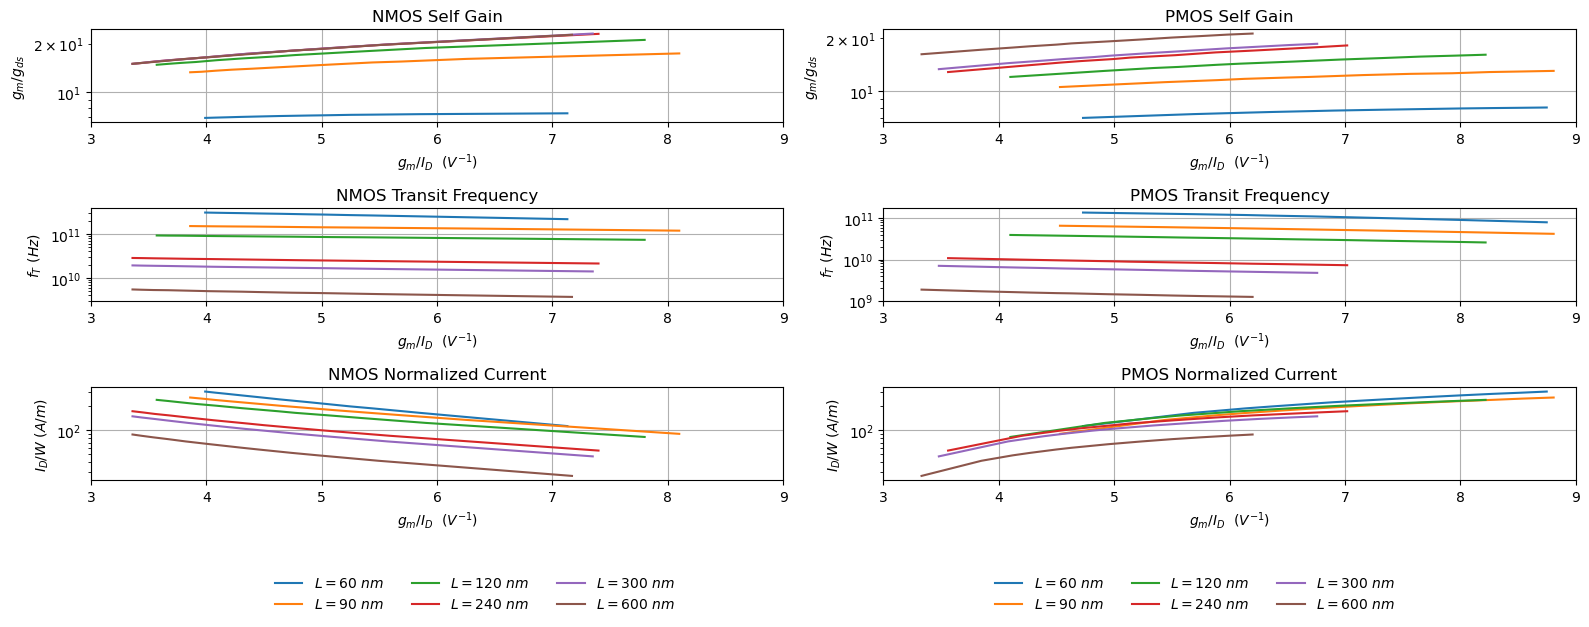

In [28]:
# Inverter transconductance efficiency
plot_inv_transconductance_efficiency_diff_lengths(transistors_params)

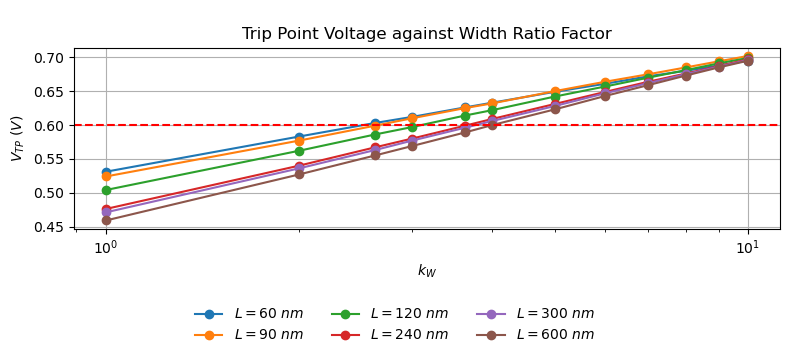

In [29]:
# Inverter trip point
plot_inv_trip_point_diff_lengths(transistors_params)

In [30]:
# Ramp perfomance close loop
Af, β, CS, CL, Vcmin, Vcmout= calc_ramp_performance_cl(VDD, N, CF)
print_ramp_perfomance_cl(Af, β, CF, CS, CL, VDD, Vcmin, Vcmout)

+-------------+---------+
| Parameter   |   Value |
+=============+=========+
| Af (V/V)    |    4    |
+-------------+---------+
| β (F/F)     |    0.25 |
+-------------+---------+
| VDD (V)     |    1.2  |
+-------------+---------+
| Vcmin (V)   |    0.6  |
+-------------+---------+
| Vcmout (V)  |    0.6  |
+-------------+---------+
| CF (fF)     |  100    |
+-------------+---------+
| CS (fF)     |  300    |
+-------------+---------+
| CL (fF)     |  400    |
+-------------+---------+


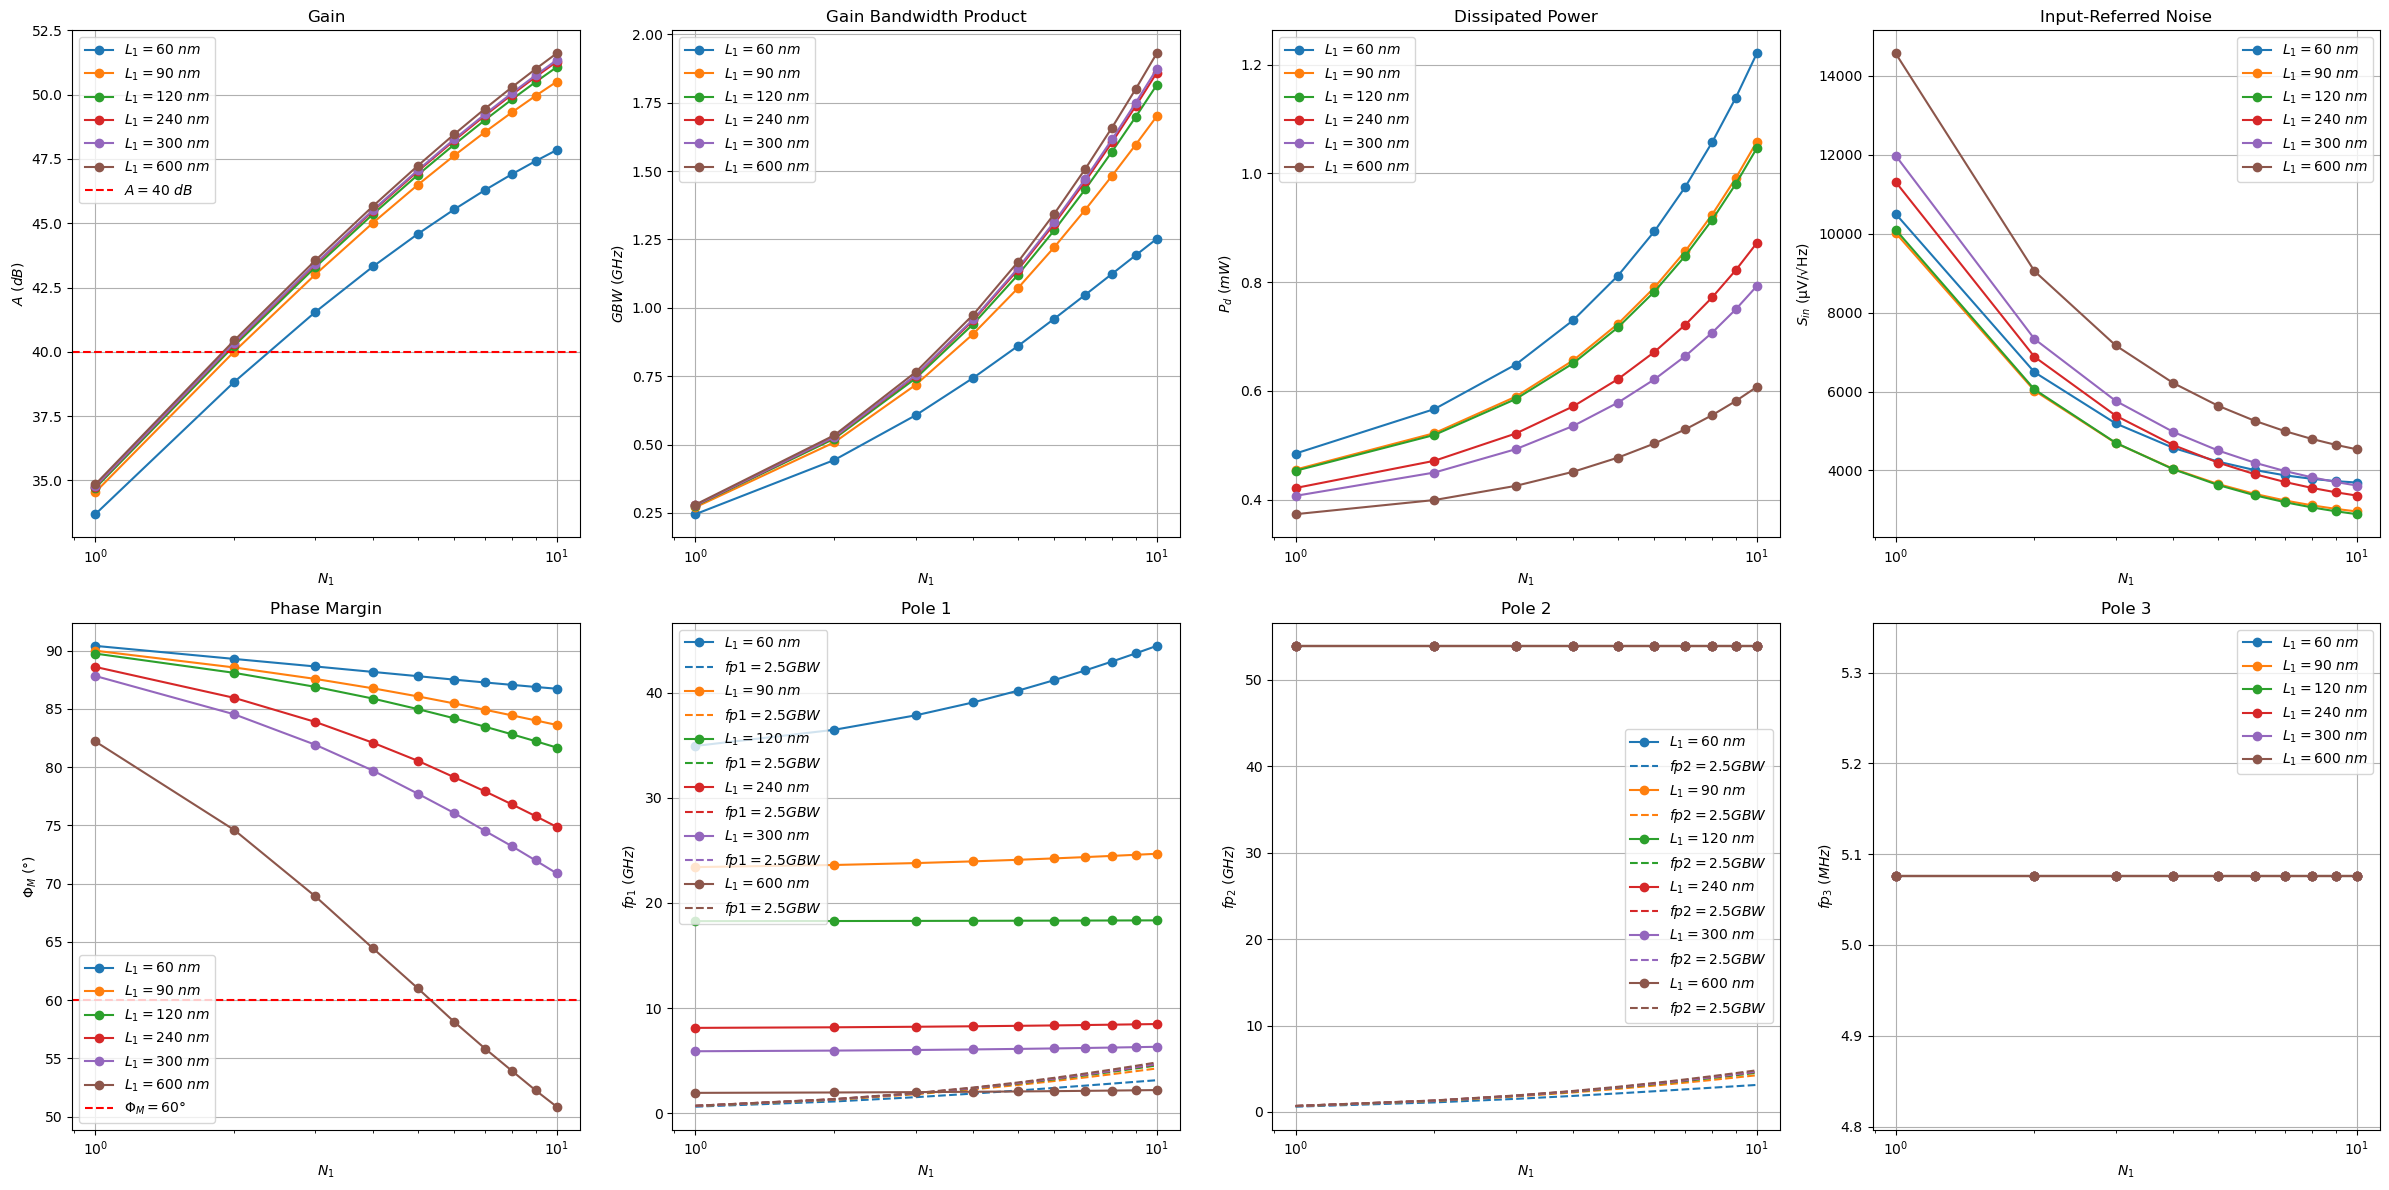

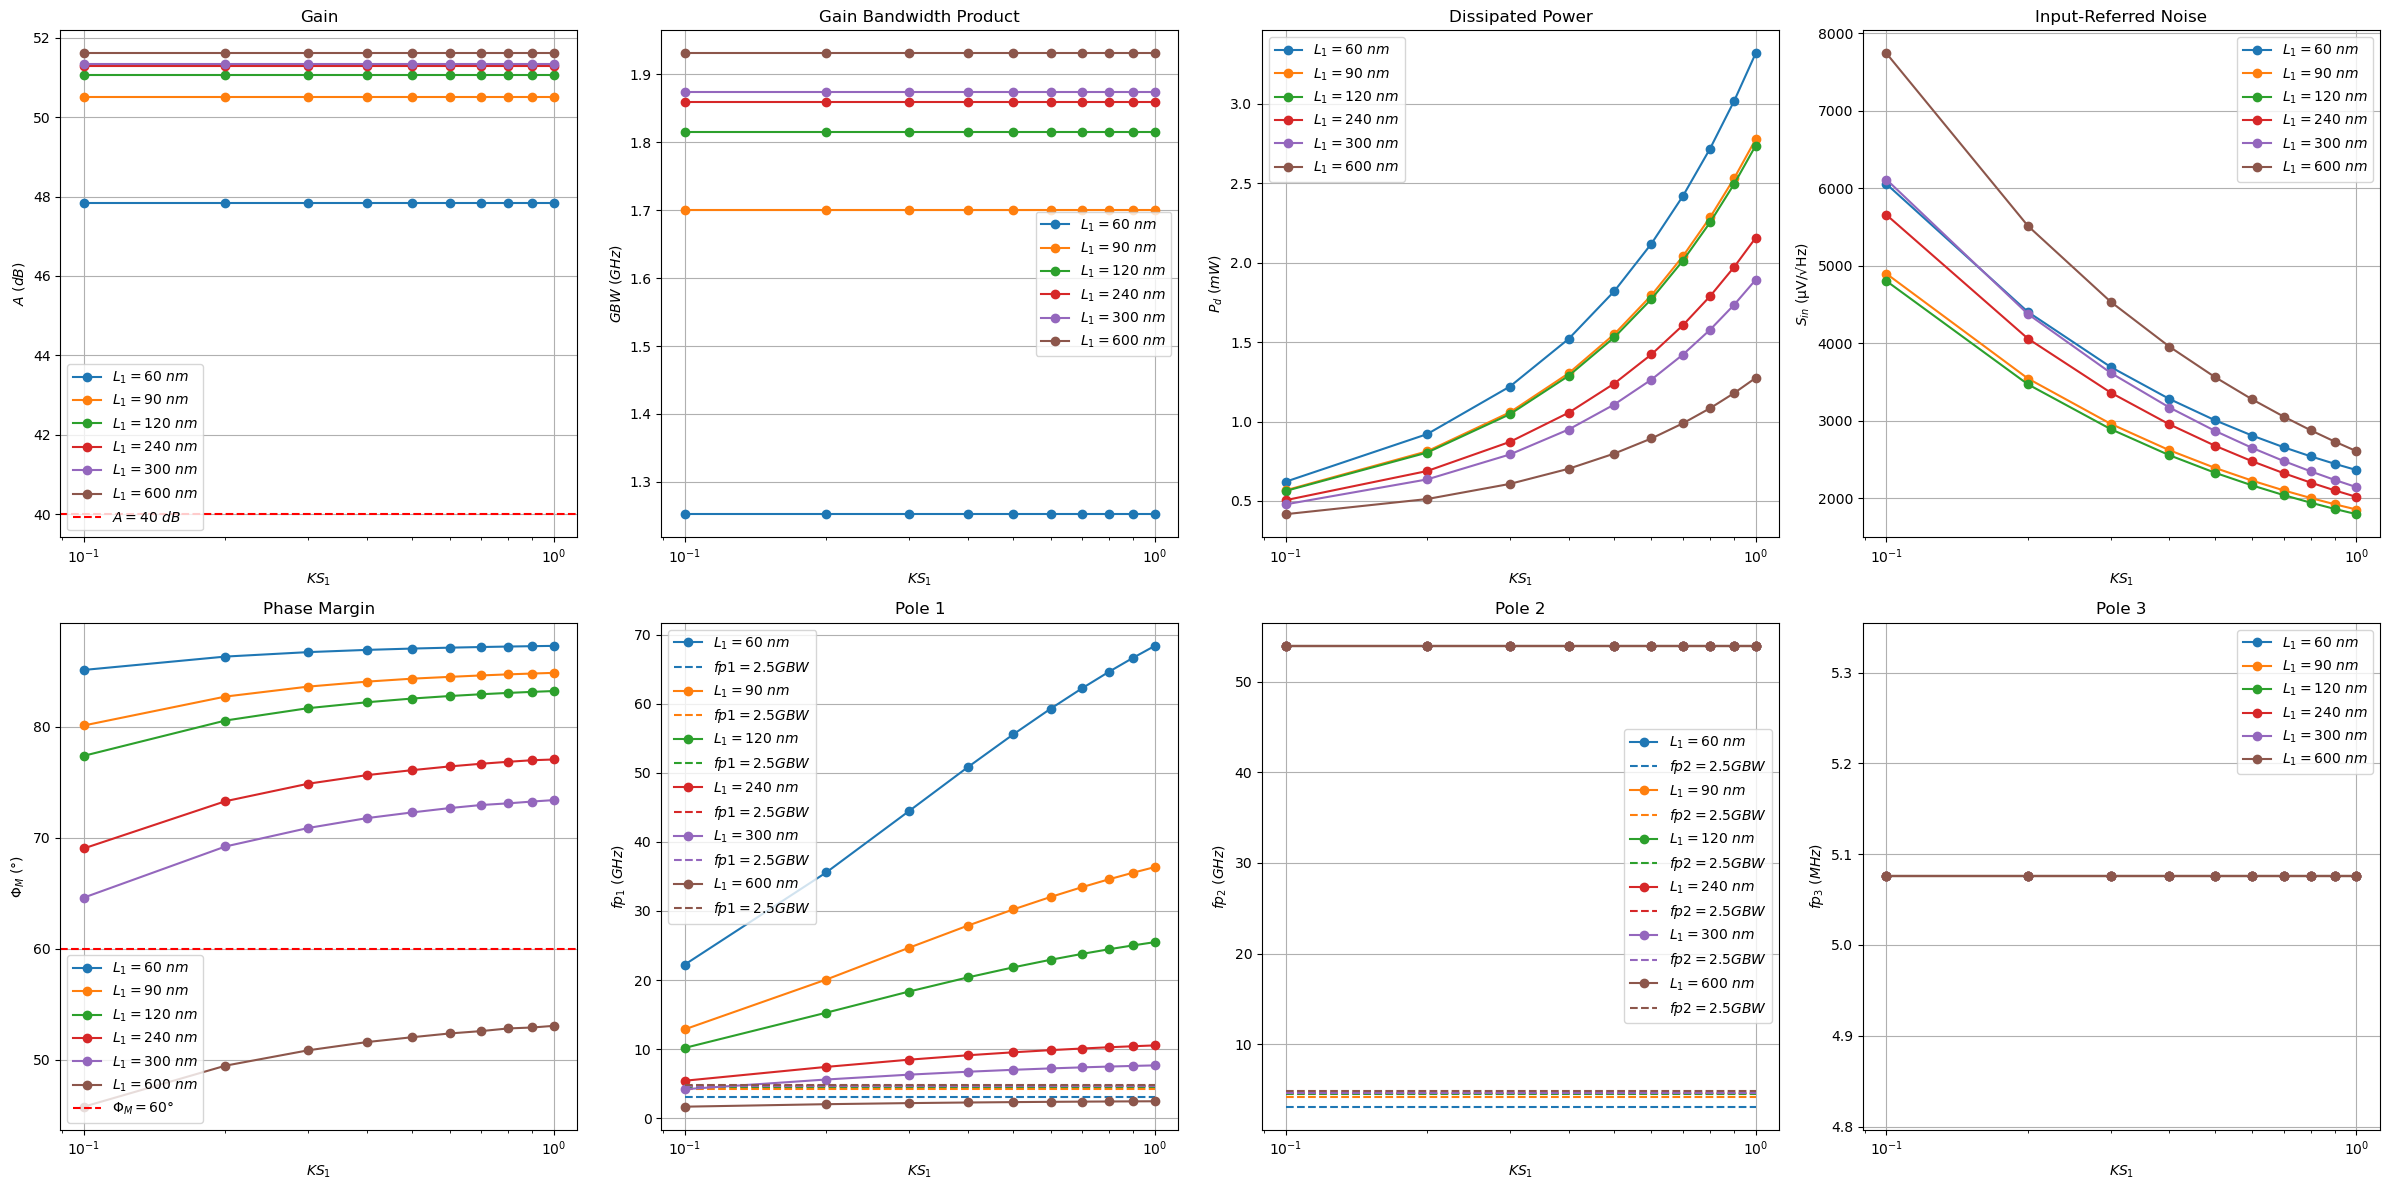

In [47]:
# Stage 1
plot_foms_diff_multipliers_lengths(transistors_params, width_ratios, ramp_2, stage_1, multipliers, freqs,
                                   cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                   N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                   N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                   N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                   VDD, CL, T, kB, γ, Δf)
plot_foms_diff_factors_lengths(transistors_params, width_ratios, ramp_2, stage_1, stage_factors, freqs,
                                     cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                     N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                     N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                     N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                     VDD, CL, T, kB, γ, Δf)

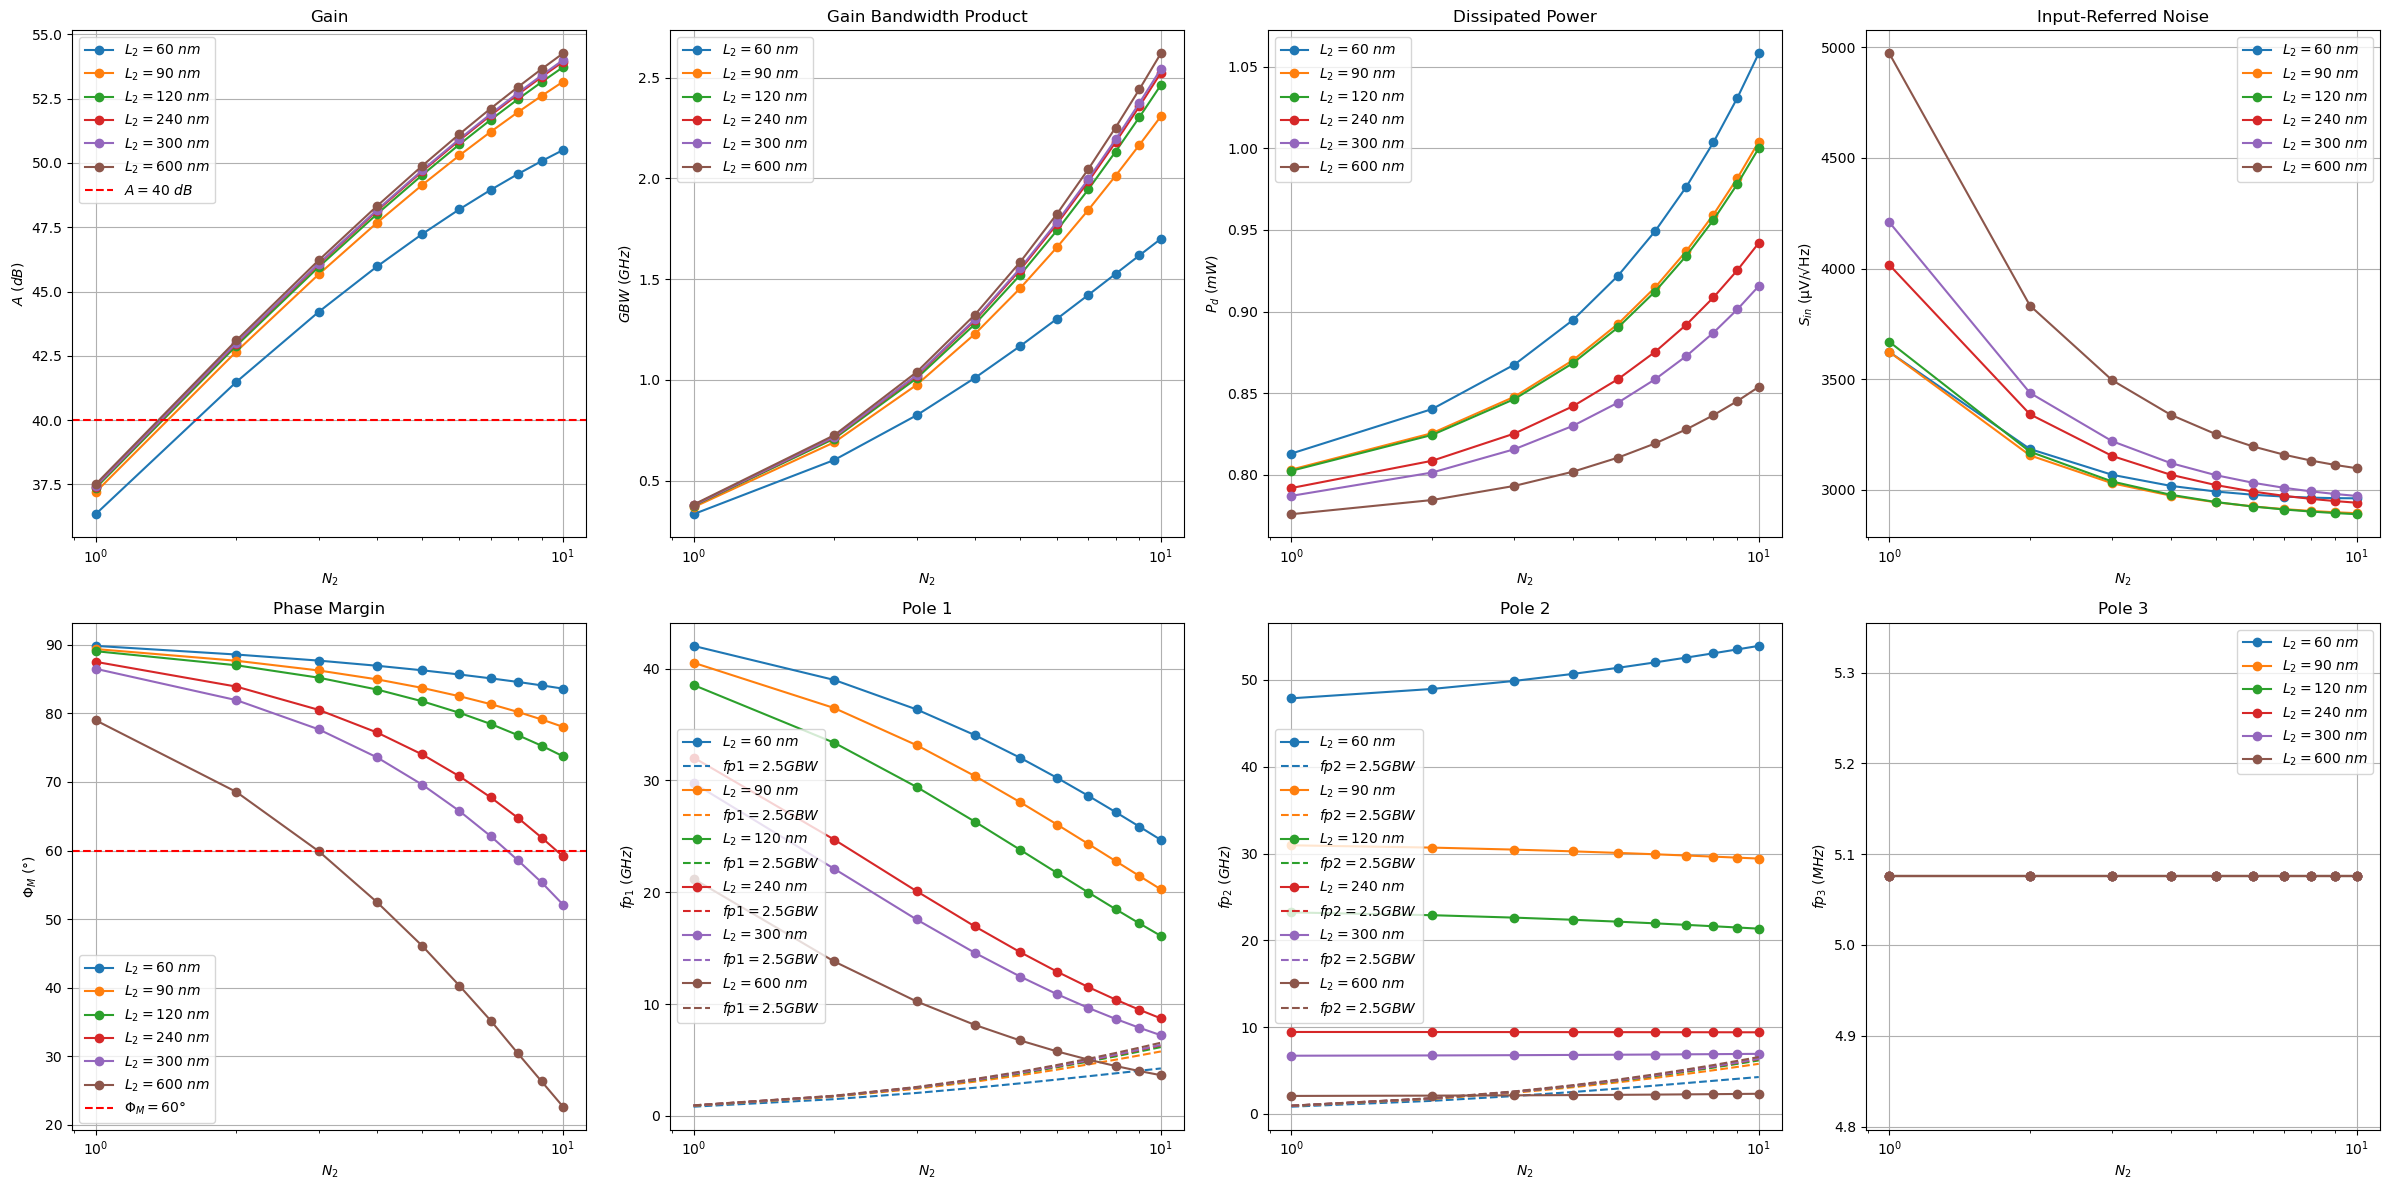

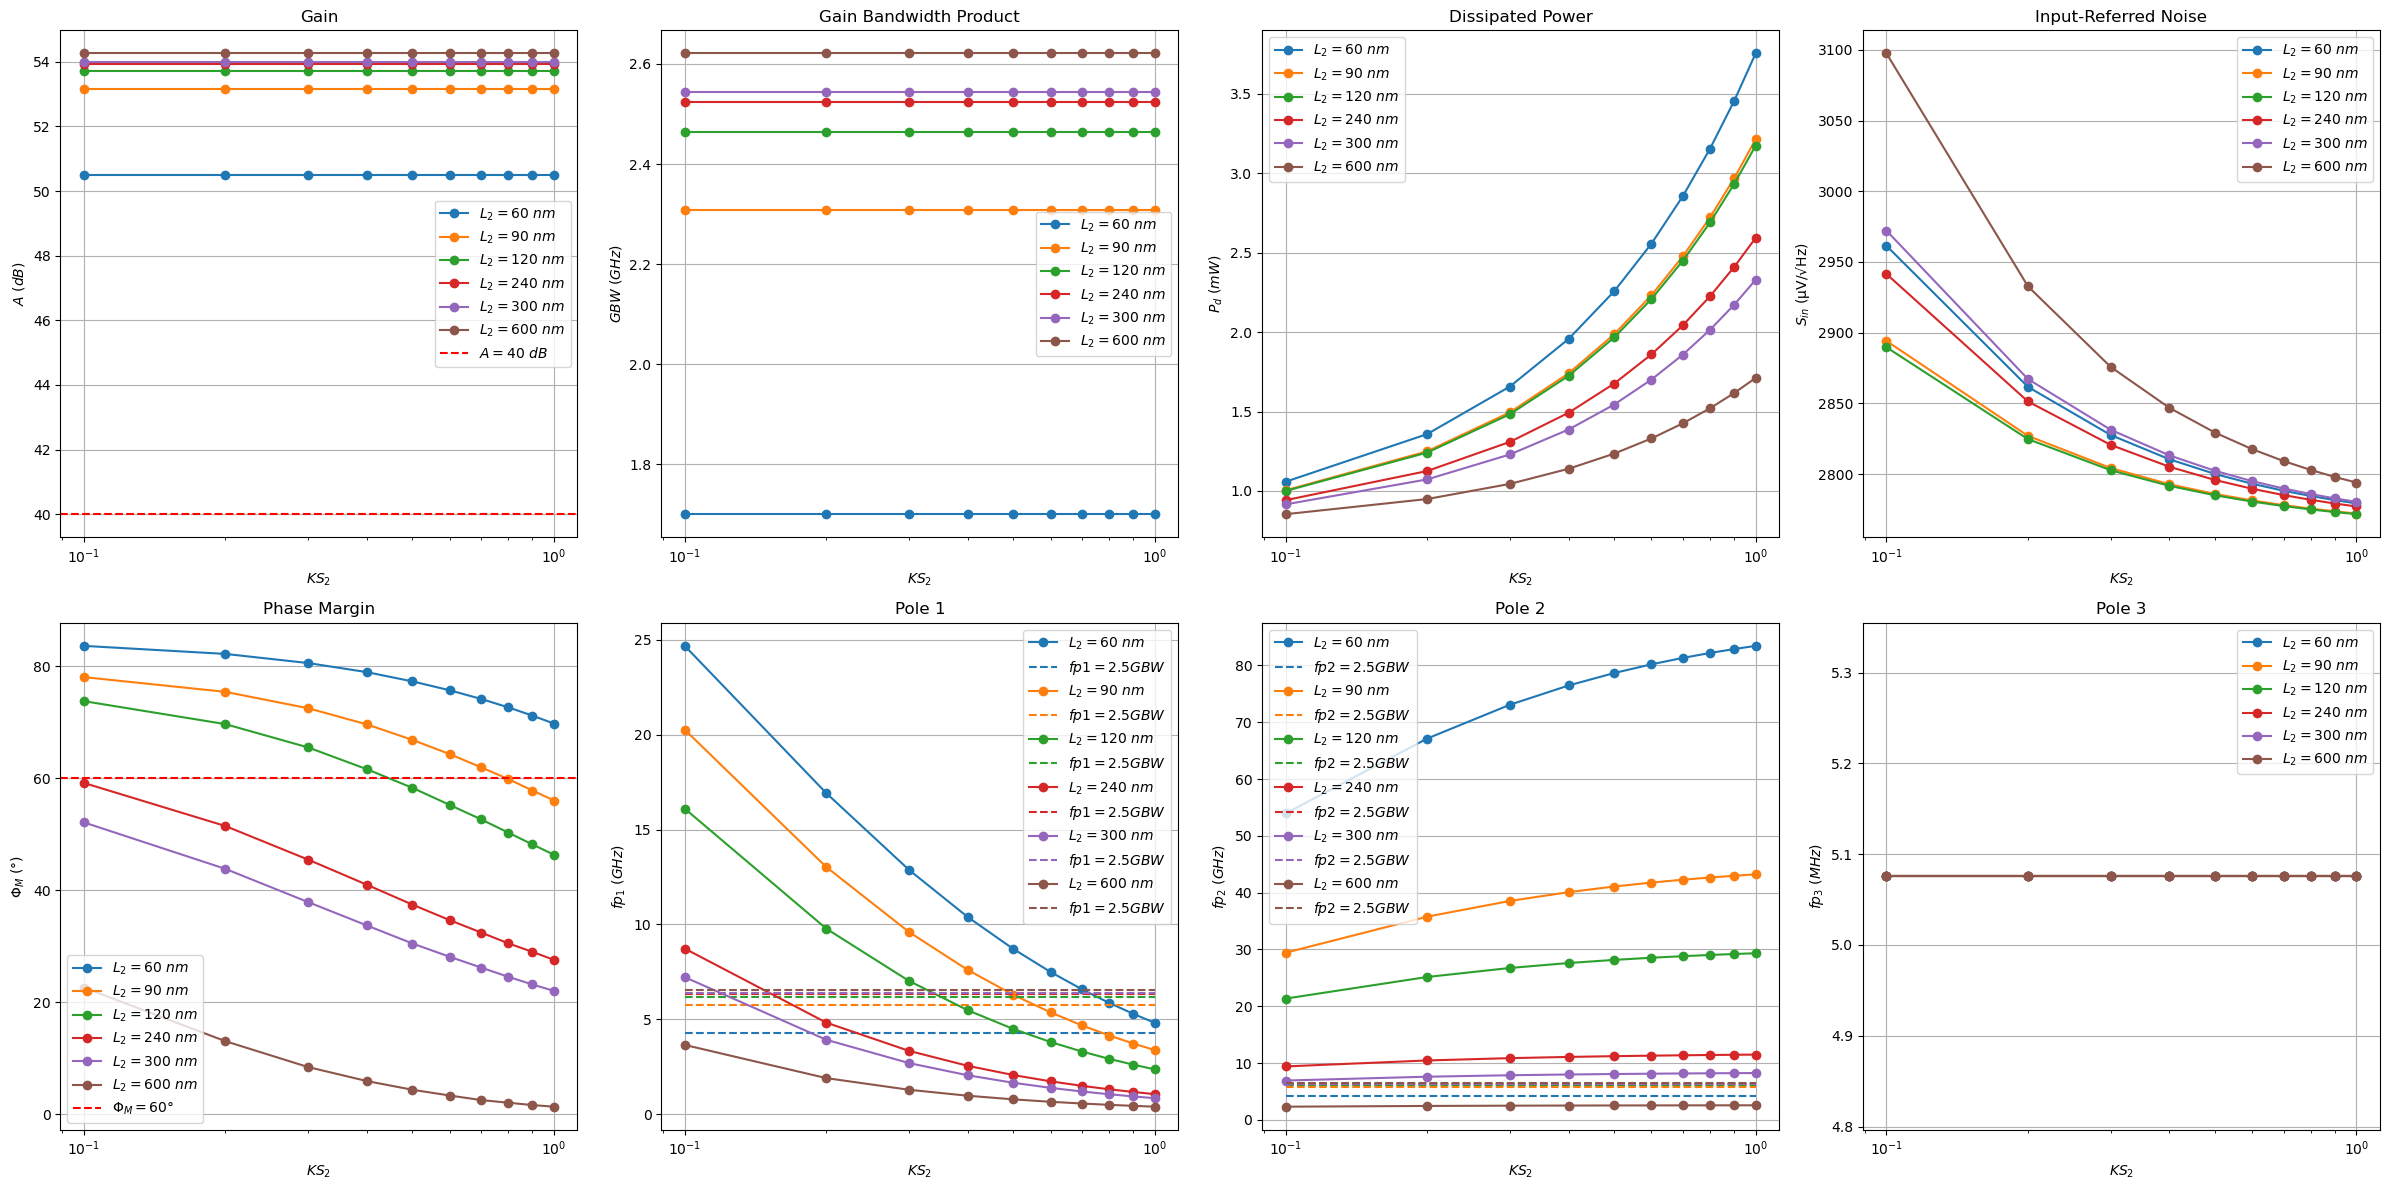

In [48]:
# Stage 2
plot_foms_diff_multipliers_lengths(transistors_params, width_ratios, ramp_2, stage_2, multipliers, freqs,
                                   cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                   N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                   N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                   N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                   VDD, CL, T, kB, γ, Δf)
plot_foms_diff_factors_lengths(transistors_params, width_ratios, ramp_2, stage_2, stage_factors, freqs,
                                     cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                     N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                     N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                     N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                     VDD, CL, T, kB, γ, Δf)

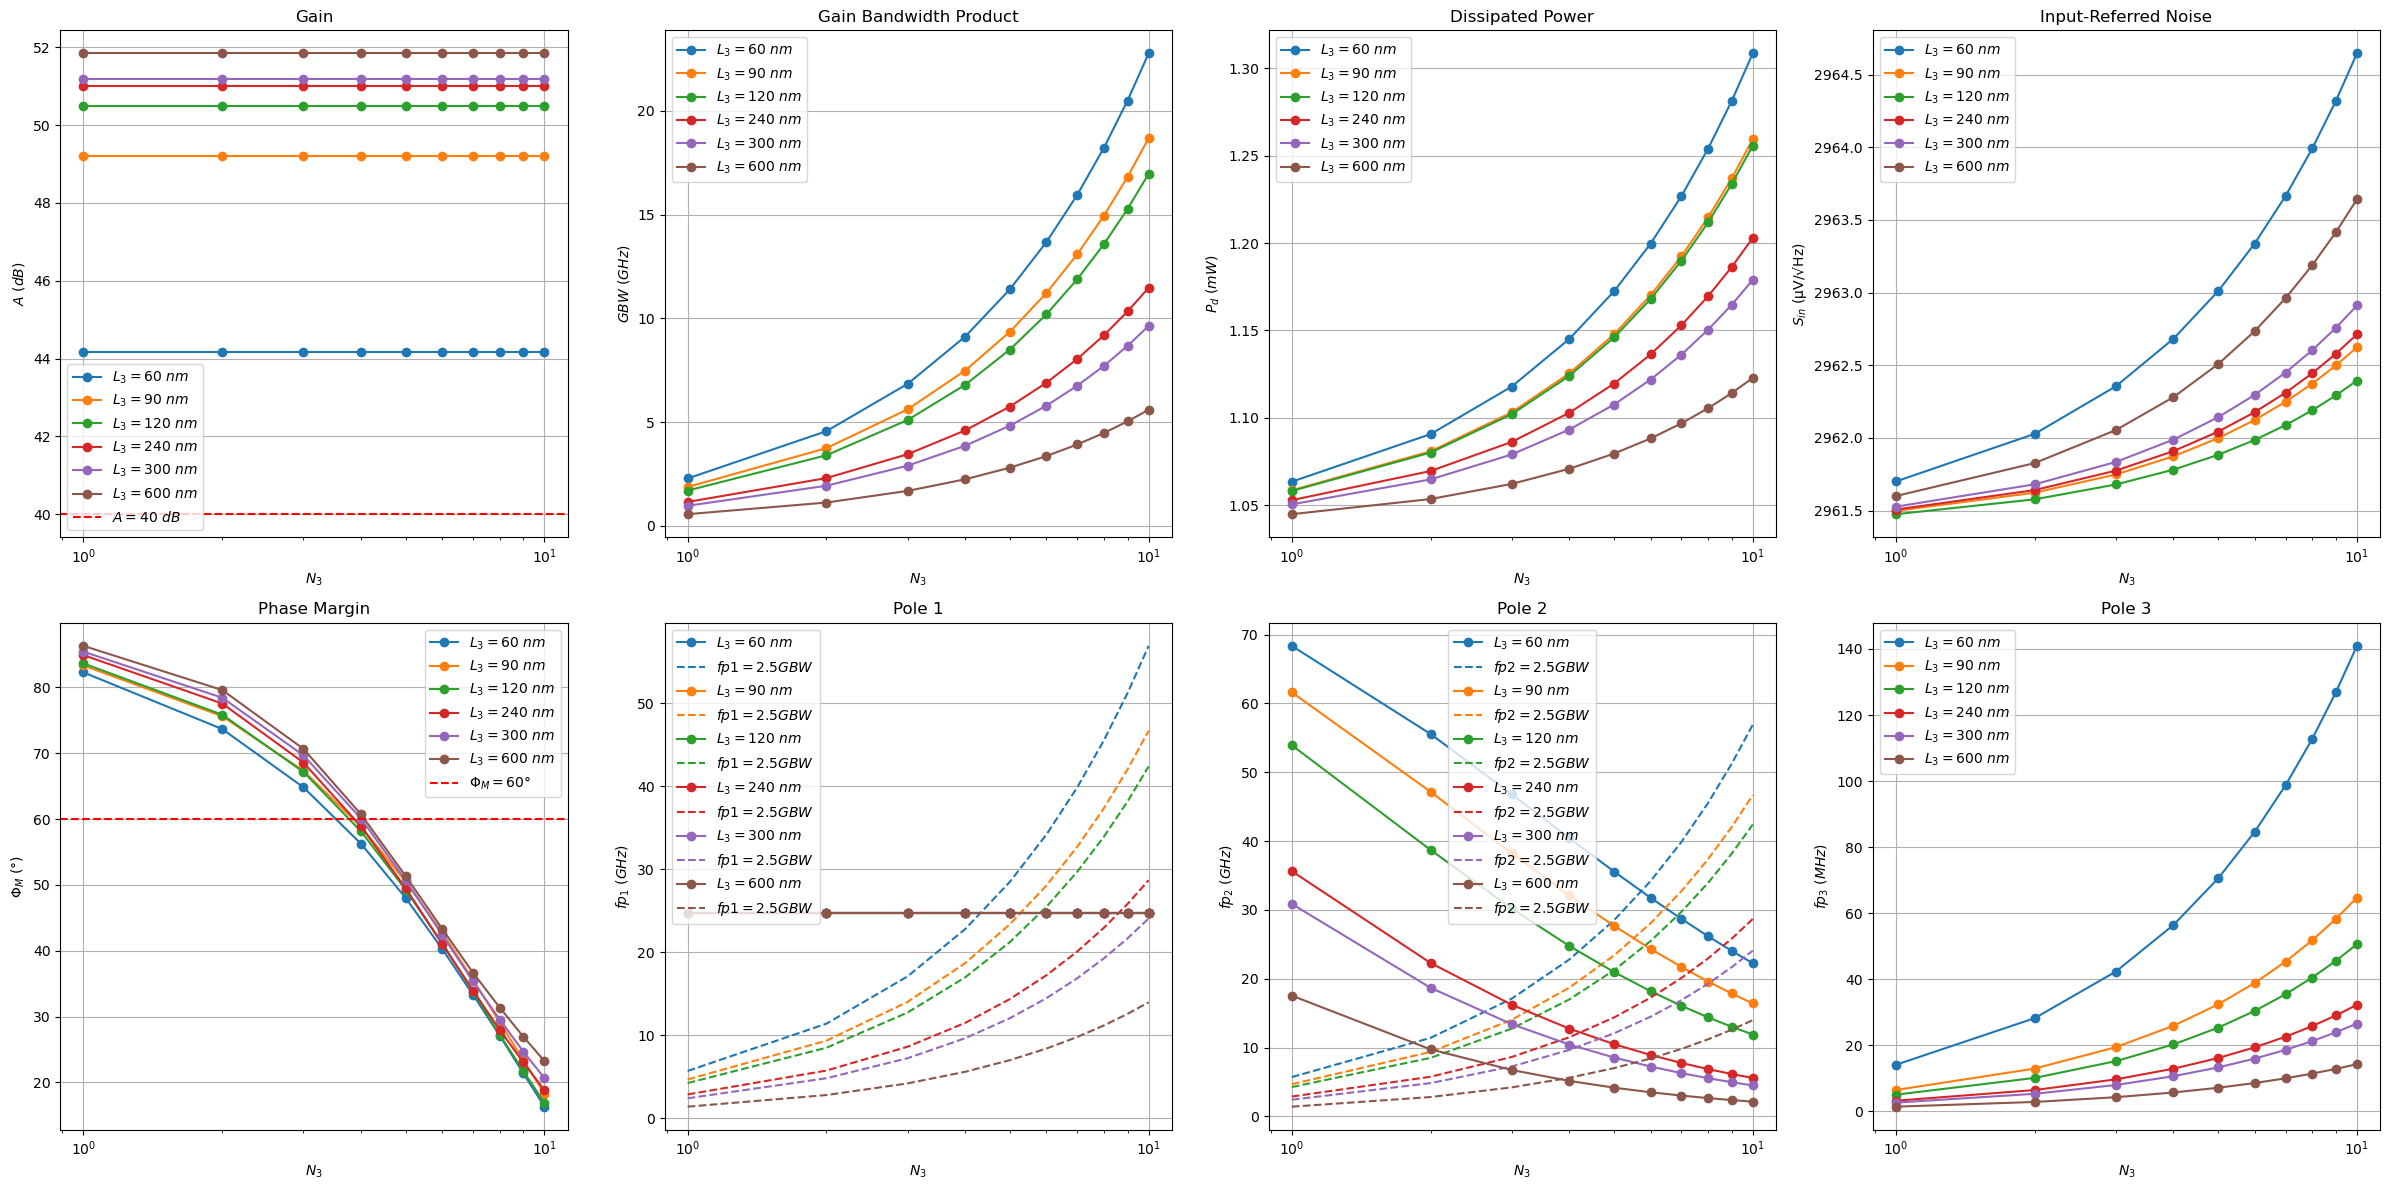

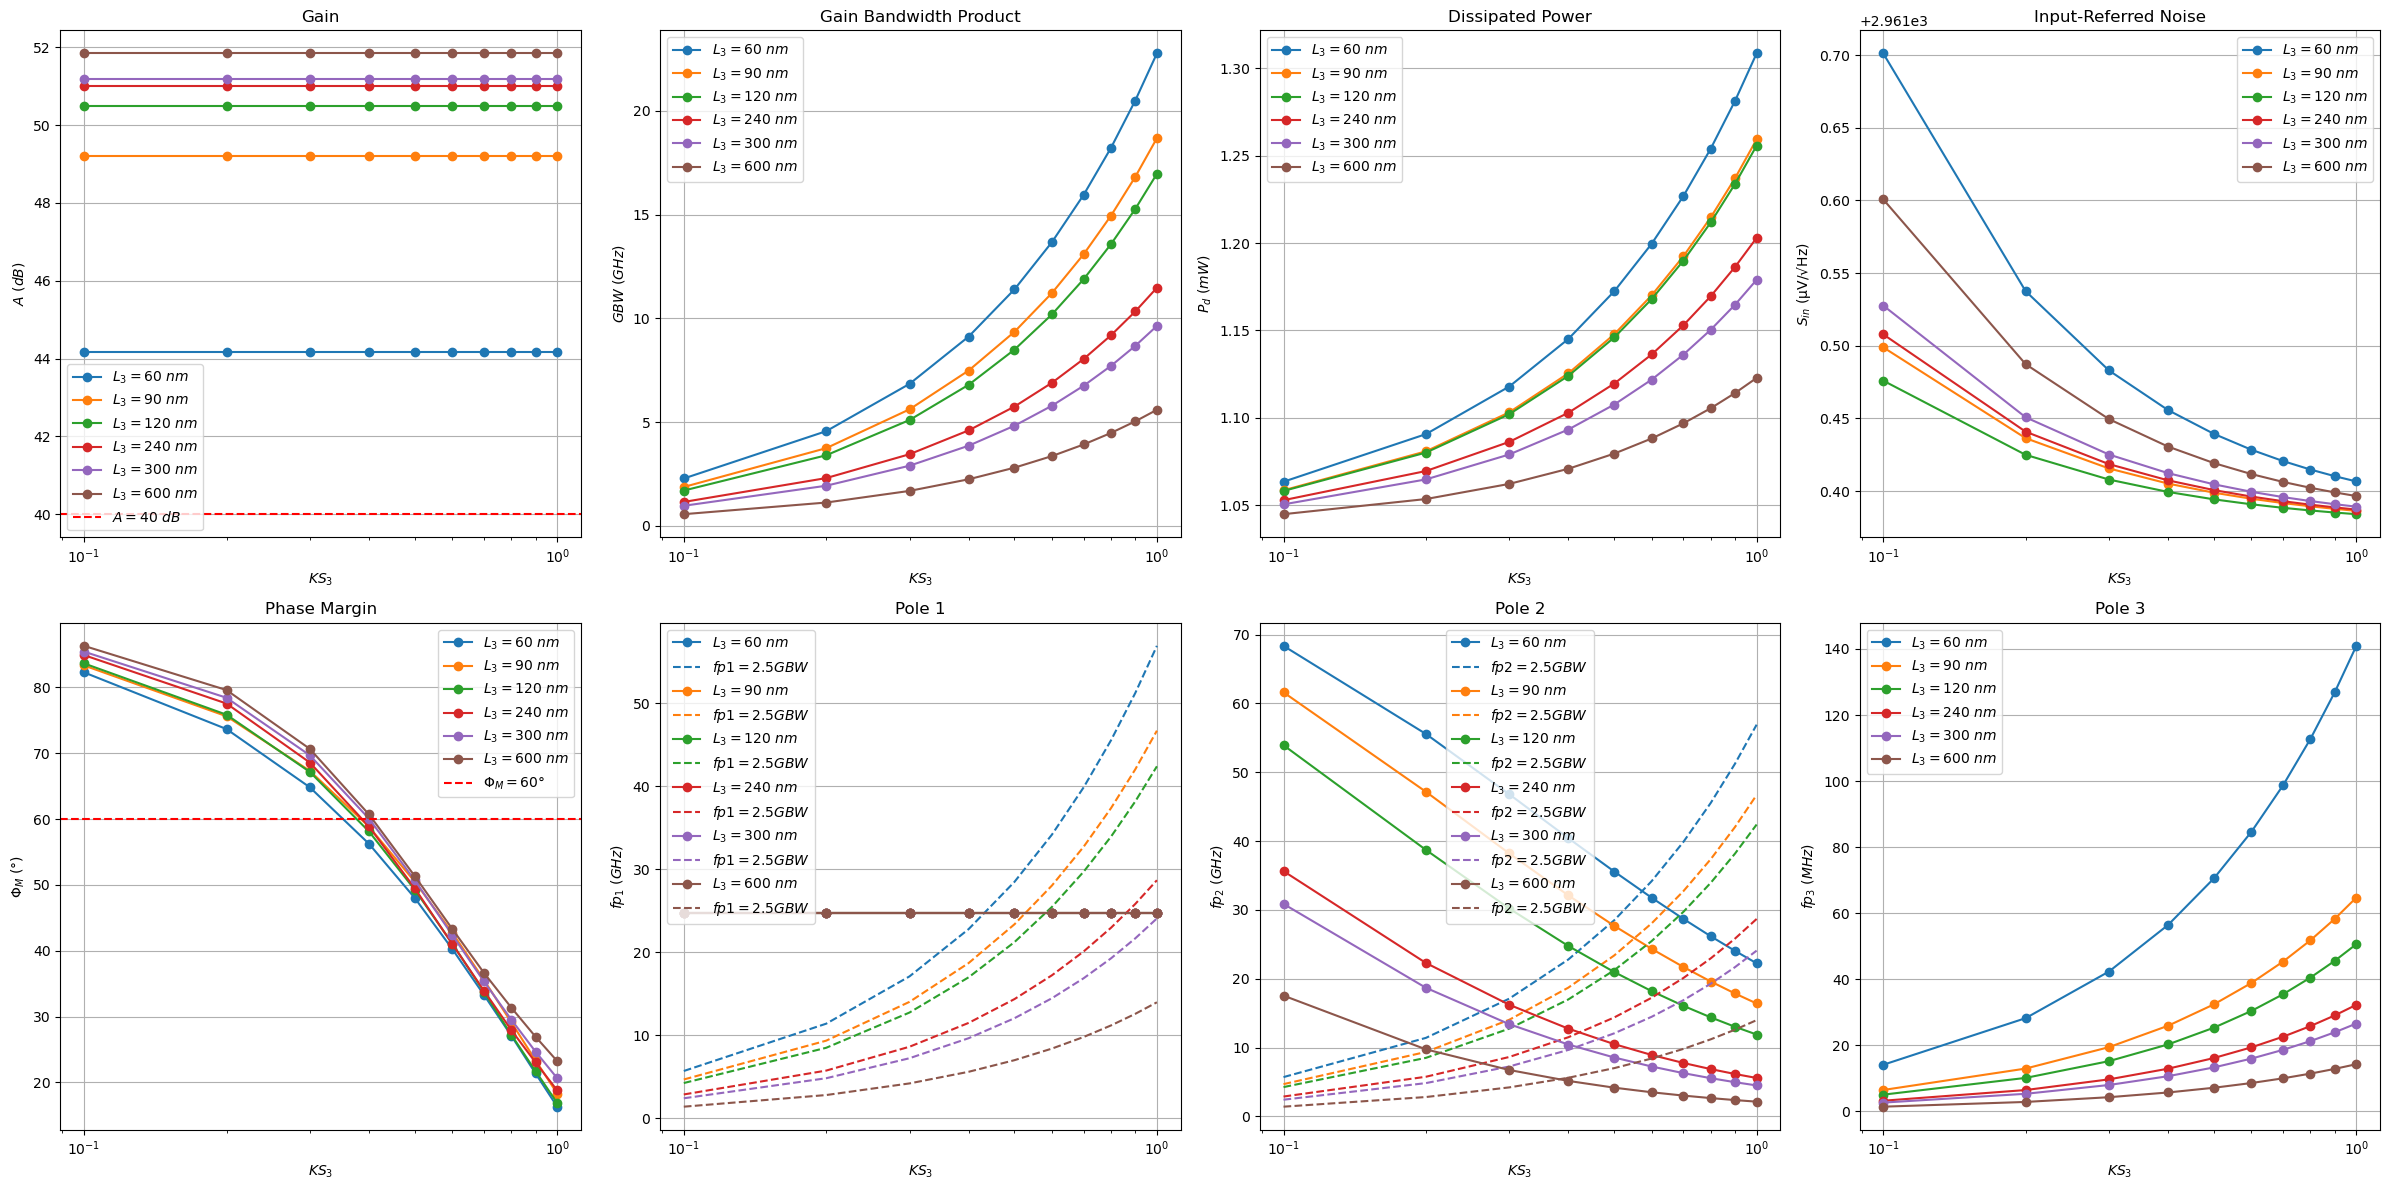

In [49]:
# Stage 3
plot_foms_diff_multipliers_lengths(transistors_params, width_ratios, ramp_2, stage_3, multipliers, freqs,
                                   cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                   N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                   N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                   N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                   VDD, CL, T, kB, γ, Δf)
plot_foms_diff_factors_lengths(transistors_params, width_ratios, ramp_2, stage_3, stage_factors, freqs,
                                     cols_idx_nmos, cols_nms_nmos, cols_idx_pmos, cols_nms_pmos,
                                     N_1, KS_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                     N_2, KS_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                     N_3, KS_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                                     VDD, CL, T, kB, γ, Δf)

In [34]:
# Ramp parameters
print_ramp_params(N_1, kW_1, KS_1,
                  N_2, kW_2, KS_2, 
                  N_3, kW_3, KS_3)

Ramp Parameters

Stage      N          kW         KS        
------------------------------------
1          9          3.625      0.6       
2          9          3.625      0.1       
3          1          4          0.1       
------------------------------------


In [35]:
# Transistors parameters
print_trans_params(
                     L_1, 
                     Vgs_n_1, Vth_n_1, Vds_n_1, Vdsat_n_1,
                     Id_n_1,   Cds_n_1,   Cgd_n_1,   Cgs_n_1,   gds_n_1,   gm_n_1,   W_n_1, 
                     Id_n_1_m, Cds_n_1_m, Cgd_n_1_m, Cgs_n_1_m, gds_n_1_m, gm_n_1_m, W_n_1_m,
                     Vgs_p_1, Vth_p_1, Vds_p_1, Vdsat_p_1,
                     Id_p_1,   Cds_p_1,   Cgd_p_1,   Cgs_p_1,   gds_p_1,   gm_p_1,   W_p_1, 
                     Id_p_1_m, Cds_p_1_m, Cgd_p_1_m, Cgs_p_1_m, gds_p_1_m, gm_p_1_m, W_p_1_m, 
                     
                     L_2, 
                     Vgs_n_2, Vth_n_2, Vds_n_2, Vdsat_n_2,
                     Id_n_2,   Cds_n_2,   Cgd_n_2,   Cgs_n_2,   gds_n_2,   gm_n_2,   W_n_2, 
                     Id_n_2_m, Cds_n_2_m, Cgd_n_2_m, Cgs_n_2_m, gds_n_2_m, gm_n_2_m, W_n_2_m,
                     Vgs_p_2, Vth_p_2, Vds_p_2, Vdsat_p_2,
                     Id_p_2,   Cds_p_2,   Cgd_p_2,   Cgs_p_2,   gds_p_2,   gm_p_2,   W_p_2, 
                     Id_p_2_m, Cds_p_2_m, Cgd_p_2_m, Cgs_p_2_m, gds_p_2_m, gm_p_2_m, W_p_2_m, 
                     
                     L_3, 
                     Vgs_n_3, Vth_n_3, Vds_n_3, Vdsat_n_3,
                     Id_n_3_m, Cds_n_3_m, Cgd_n_3_m, Cgs_n_3_m, gds_n_3_m, gm_n_3_m, W_n_3_m,
                     Vgs_p_3, Vth_p_3, Vds_p_3, Vdsat_p_3,
                     Id_p_3_m, Cds_p_3_m, Cgd_p_3_m, Cgs_p_3_m, gds_p_3_m, gm_p_3_m, W_p_3_m 
                )

Transistors Parameters

Transistor Id (µA)    Vgs (mV)   Vth (mV)   Vds (mV)   Vdsat (mV)   Cds (zF)   Cgd (aF)   Cgs (aF)   gds (µS)   gm (µS)    W (nm)     L (nm)    
------------------------------------------------------------------------------------------------------------------------------------------------
NM1        642.600    596.000    168.000    596.000    302.000      912.600    1857.600   26568.000  164.160    2889.000   6480       300       
PM1        -642.600   -604.000   -262.000   -604.000   -297.000     32994.000  5886.000   84240.000  198.180    3105.000   23490      300       
NM1D       71.400     596.000    168.000    596.000    302.000      101.400    206.400    2952.000   18.240     321.000    720        300       
PM1D       -71.400    -604.000   -262.000   -604.000   -297.000     3666.000   654.000    9360.000   22.020     345.000    2610       300       
NM2        107.100    596.000    168.000    596.000    302.000      152.100    309.600    4428.000   27.36

In [ ]:
# Ramps perfomance open loop
A_c_ramp, BW_c_ramp, GBW_c_ramp, ts_c_ramp, Vos_c_ramp, SR_c_ramp, Pd_c_ramp, Sin_c_ramp = calc_ramp_performance_ol(ramp_1, 
                                                                                                        N_1, Id_1, gm_1, gds_1, 
                                                                                                        N_2, Id_2, gm_2, gds_2, 
                                                                                                        N_3, Id_3, Cds_3, Cgd_3, gm_3, gds_3, Vdsat_p_3, Vdsat_n_3,
                                                                                                        VDD, CL, T, kB, γ, ϵ, β, Δf)
A_cd_ramp, BW_cd_ramp, GBW_cd_ramp, ts_cd_ramp, Vos_cd_ramp, SR_cd_ramp, Pd_cd_ramp, Sin_cd_ramp = calc_ramp_performance_ol(ramp_2, 
                                                                                                               N_1, Id_1, gm_1, gds_1, 
                                                                                                               N_2, Id_2, gm_2, gds_2, 
                                                                                                               N_3, Id_3, Cds_3, Cgd_3, gm_3, gds_3, Vdsat_p_3, Vdsat_n_3,
                                                                                                               VDD, CL, T, kB, γ, ϵ, β, Δf)
PM_1 = ramp_phase_margin(ramp_1, freqs, 
                         N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                         CL)
PM_2 = ramp_phase_margin(ramp_2, freqs, 
                         N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                         CL)
print_ramp_performances(ramp_1, A_c_ramp, BW_c_ramp, GBW_c_ramp, ts_c_ramp, Vos_c_ramp, SR_c_ramp, Pd_c_ramp, Sin_c_ramp, PM_1,
                        ramp_2, A_cd_ramp, BW_cd_ramp, GBW_cd_ramp, ts_cd_ramp, Vos_cd_ramp, SR_cd_ramp, Pd_cd_ramp, Sin_cd_ramp, PM_2)

+--------------+----------------+---------------------+
|              |   Conventional |   Critically Damped |
+==============+================+=====================+
| A (dB)       |         73.785 |              54.997 |
+--------------+----------------+---------------------+
| BW (MHz)     |          1.436 |               1.436 |
+--------------+----------------+---------------------+
| GBW (MHz)    |       7019.78  |             807.097 |
+--------------+----------------+---------------------+
| ts (ps)      |        417.64  |            3632.45  |
+--------------+----------------+---------------------+
| SR (V/µs)    |         18.05  |              18.05  |
+--------------+----------------+---------------------+
| Vos (mV)     |        546     |             546     |
+--------------+----------------+---------------------+
| Pd (mW)      |          0.908 |               1.008 |
+--------------+----------------+---------------------+
| Sin (µV/√Hz) |        817.912 |            274

In [37]:
# Stages Perfomance in open loop
A1_c_ramp, Pd1_c_ramp, Sin1_c_ramp, fp1_c_ramp, fz1_c_ramp = calc_stage_perfomance_ol(ramp_1, stage_1,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
A1_cd_ramp, Pd1_cd_ramp, Sin1_cd_ramp, fp1_cd_ramp, fz1_cd_ramp = calc_stage_perfomance_ol(ramp_2, stage_1,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
A2_c_ramp, Pd2_c_ramp, Sin2_c_ramp, fp2_c_ramp, fz2_c_ramp = calc_stage_perfomance_ol(ramp_1, stage_2,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
A2_cd_ramp, Pd2_cd_ramp, Sin2_cd_ramp, fp2_cd_ramp, fz2_cd_ramp = calc_stage_perfomance_ol(ramp_2, stage_2,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
A3_c_ramp, Pd3_c_ramp, Sin3_c_ramp, fp3_c_ramp, fz3_c_ramp = calc_stage_perfomance_ol(ramp_1, stage_3,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
A3_cd_ramp, Pd3_cd_ramp, Sin3_cd_ramp, fp3_cd_ramp, fz3_cd_ramp = calc_stage_perfomance_ol(ramp_2, stage_3,
                         N_1, Id_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                         N_2, Id_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                         N_3, Id_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3,
                         VDD, CL, kB, T, γ, Δf)
print_stages_performances_ol(ramp_1, ramp_2,  
                             A1_c_ramp, Pd1_c_ramp, Sin1_c_ramp, fp1_c_ramp, fz1_c_ramp,
                             A1_cd_ramp, Pd1_cd_ramp, Sin1_cd_ramp, fp1_cd_ramp, fz1_cd_ramp,
                             A2_c_ramp, Pd2_c_ramp, Sin2_c_ramp, fp2_c_ramp, fz2_c_ramp,
                             A2_cd_ramp, Pd2_cd_ramp, Sin2_cd_ramp, fp2_cd_ramp, fz2_cd_ramp,
                             A3_c_ramp, Pd3_c_ramp, Sin3_c_ramp, fp3_c_ramp, fz3_c_ramp,
                             A3_cd_ramp, Pd3_cd_ramp, Sin3_cd_ramp, fp3_cd_ramp, fz3_cd_ramp)

+-----------+----------------+---------------------+-----------+----------------+---------------------+-----------+----------------+---------------------+
|           |   Conventional |   Critically Damped |           |   Conventional |   Critically Damped |           |   Conventional |   Critically Damped |
+===========+================+=====================+===========+================+=====================+===========+================+=====================+
| A₁ (dB)   |         24.372 |              14.978 | A₂ (dB)   |         24.372 |              14.978 | A₃ (dB)   |         25.041 |              25.041 |
+-----------+----------------+---------------------+-----------+----------------+---------------------+-----------+----------------+---------------------+
| Pd₁ (µW)  |        771.12  |             856.8   | Pd₂ (mW)  |        128.52  |             142.8   | Pd₃ (mW)  |          8.664 |               8.664 |
+-----------+----------------+---------------------+-----------+------

In [38]:
# Target poles
fp1_gbw_1, fp2_gbw_1 = calc_target_poles(fp1_c_ramp, fp2_c_ramp, GBW_c_ramp)
fp1_gbw_2, fp2_gbw_2 = calc_target_poles(fp1_cd_ramp, fp2_cd_ramp, GBW_cd_ramp)
print_target_poles(ramp_1, fp1_gbw_1, fp2_gbw_1,
                   ramp_2, fp1_gbw_2, fp2_gbw_2)

+---------+----------------+---------------------+
|         |   Conventional |   Critically Damped |
+=========+================+=====================+
| fp1/gbw |          0.298 |               5.288 |
+---------+----------------+---------------------+
| fp2/gbw |          0.226 |               4.336 |
+---------+----------------+---------------------+


In [39]:
# Clock frequency
fs_c_ramp = calc_sample_freq(D, ts_c_ramp)
fs_cd_ramp = calc_sample_freq(D, ts_cd_ramp)
print_sample_freq(ramp_1, fs_c_ramp, ramp_2, fs_cd_ramp)

+------------+----------------+---------------------+
|            |   Conventional |   Critically Damped |
+============+================+=====================+
| fclk (MHz) |         1194.8 |               137.4 |
+------------+----------------+---------------------+


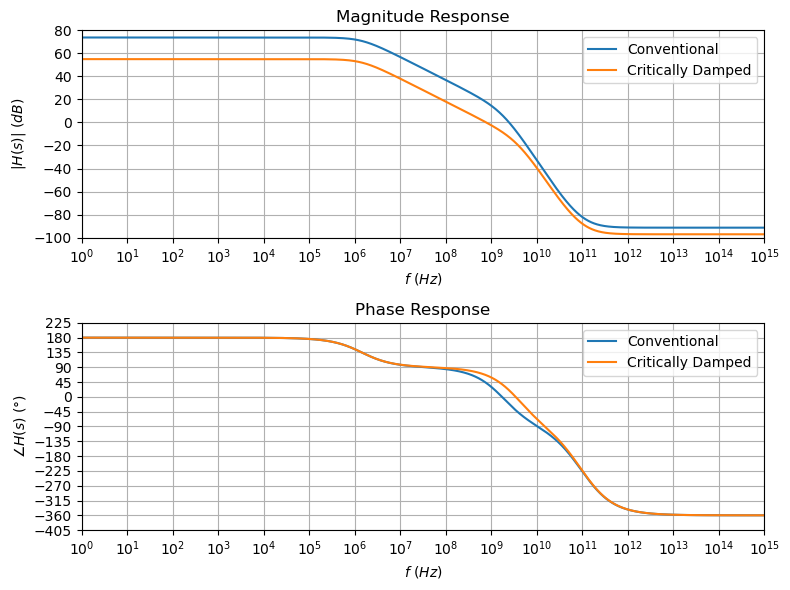

In [40]:
# Ramps frequency response in open loop
mag_c_ramp, phase_c_ramp, freq_c_ramp = calc_ramp_frequency_response_ol(ramp_1, freqs,
                                                                     N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                                                     N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                                                     N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                                                                     CL)
mag_cd_ramp, phase_cd_ramp, freq_cd_ramp = calc_ramp_frequency_response_ol(ramp_2, freqs,
                                                                           N_1, Cds_1, Cgd_1, Cgs_1, gds_1, gm_1, 
                                                                           N_2, Cds_2, Cgd_2, Cgs_2, gds_2, gm_2, 
                                                                           N_3, Cds_3, Cgd_3, Cgs_3, gds_3, gm_3, 
                                                                           CL)
plot_frequency_responses_ol(ramp_1, mag_c_ramp, phase_c_ramp, freq_c_ramp,
                            ramp_2, mag_cd_ramp, phase_cd_ramp, freq_cd_ramp)

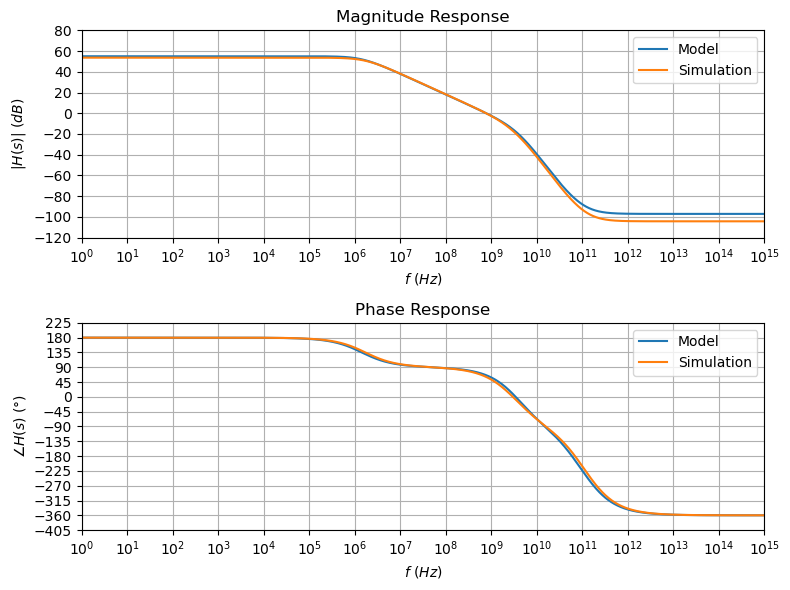

In [41]:
# Compare theory and simulation
comp_frequency_responses_ol(mag_cd_ramp, phase_cd_ramp, freq_cd_ramp, designs['A'])

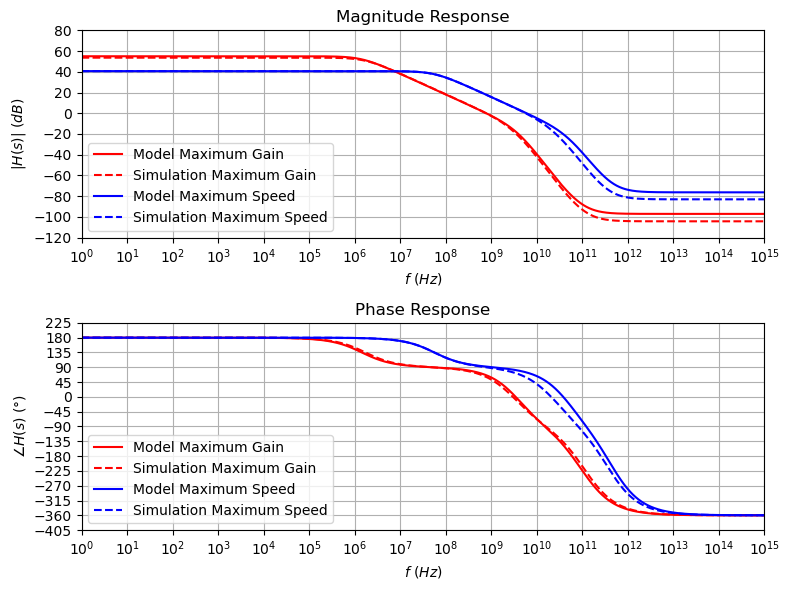

In [ ]:
N_1_A, L_1_A, kW_1_A, KS_1_A, N_2_A, L_2_A, kW_2_A, KS_2_A, N_3_A, L_3_A, kW_3_A, KS_3_A = get_ramp_params('A')
Cds_1_A, Cgd_1_A, Cgs_1_A, gds_1_A, gm_1_A, Cds_2_A, Cgd_2_A, Cgs_2_A, gds_2_A, gm_2_A, Cds_3_A, Cgd_3_A, Cgs_3_A, gds_3_A, gm_3_A = get_ramp_chrts(L_1_A, kW_1_A, KS_1_A, 
                                                                                                                                                    L_2_A, kW_2_A, KS_2_A, 
                                                                                                                                                    L_3_A, kW_3_A, KS_3_A)
mag_A, phase_A, freq_A = calc_ramp_frequency_response_ol(ramp_2, freqs, 
                                                         N_1_A, Cds_1_A, Cgd_1_A, Cgs_1_A, gds_1_A, gm_1_A, 
                                                         N_2_A, Cds_2_A, Cgd_2_A, Cgs_2_A, gds_2_A, gm_2_A, 
                                                         N_3_A, Cds_3_A, Cgd_3_A, Cgs_3_A, gds_3_A, gm_3_A, 
                                                         CL)

N_1_GBW, L_1_GBW, kW_1_GBW, KS_1_GBW, N_2_GBW, L_2_GBW, kW_2_GBW, KS_2_GBW, N_3_GBW, L_3_GBW, kW_3_GBW, KS_3_GBW = get_ramp_params('GBW')
Cds_1_GBW, Cgd_1_GBW, Cgs_1_GBW, gds_1_GBW, gm_1_GBW, Cds_2_GBW, Cgd_2_GBW, Cgs_2_GBW, gds_2_GBW, gm_2_GBW, Cds_3_GBW, Cgd_3_GBW, Cgs_3_GBW, gds_3_GBW, gm_3_GBW = get_ramp_chrts(L_1_GBW, kW_1_GBW, KS_1_GBW, 
                                                                                                                                                                                  L_2_GBW, kW_2_GBW, KS_2_GBW, 
                                                                                                                                                                                  L_3_GBW, kW_3_GBW, KS_3_GBW)
mag_GBW, phase_GBW, freq_GBW = calc_ramp_frequency_response_ol(ramp_2, freqs, 
                                                         N_1_GBW, Cds_1_GBW, Cgd_1_GBW, Cgs_1_GBW, gds_1_GBW, gm_1_GBW, 
                                                         N_2_GBW, Cds_2_GBW, Cgd_2_GBW, Cgs_2_GBW, gds_2_GBW, gm_2_GBW, 
                                                         N_3_GBW, Cds_3_GBW, Cgd_3_GBW, Cgs_3_GBW, gds_3_GBW, gm_3_GBW, 
                                                         CL)

comp_freq_resps_ol(designs,
                   mag_A, phase_A, freq_A,
                   mag_GBW, phase_GBW, freq_GBW)